# Chasing Ghosts in Ironman Data

This V2 notebook supports the flagship article *Chasing Ghosts in Ironman Data*.

The core article question is simple:

> Is the strange thing a whole race, a broken row, or an unusual athlete profile?

The notebook separates:

- `event_context_flag`: likely shortened/cancelled/altered leg or course-level timing convention
- `record_integrity_strict_flag`: hard row-level arithmetic/timing issue
- `rank_audit_flag`: soft source-rank caveat, not a standalone anomaly
- `individual_profile_flag`: unusual but plausible athlete profile after event-context and strict row-integrity issues are removed

## Table of Contents

1. [Setup](#setup)
2. [Load data and parse times](#load-data)
3. [Nominal distances, speeds, and event context](#event-context)
4. [Analysis table and relative percentiles](#features)
5. [Record integrity checks](#record-integrity)
6. [Hard limits after event-context adjustment](#hard-limits)
7. [Consistency profile checks](#consistency)
8. [Robust residual models](#model-flags)
9. [Combined review families](#combined)
10. [Article-facing tables and figures](#article-outputs)
11. [Case evidence](#cases)
12. [PRO vs non-PRO sensitivity](#pro-sensitivity)
13. [Validation](#validation)
14. [Article summary](#summary)

## 1. Setup <a id="setup"></a>

This notebook is meant to be read on GitHub, not only executed locally.

The thresholds below are **conservative defaults**, not scientific constants. They are used to route rows into review categories:

- event/course context
- strict record integrity
- individual profile surprise

The `PARAMETER_REGISTRY` table documents each threshold, the unit, the reason it exists, and how sensitive the result is to changing it. If you change a value in the config, update the registry in the same cell so the notebook remains auditable.

In [48]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
DATA_DIR = Path.home() / "coachcox_results_csv"

# The analysis compares athletes inside event-gender cohorts. Rows without a
# known binary race-result gender are counted in the cleaning audit, then
# excluded from the main percentile and model workflow.
VALID_GENDERS = ["Female", "Male"]

TIME_COLS = [
    "Overall Time",
    "Swim Time",
    "Bike Time",
    "Run Time",
    "Transition 1 Time",
    "Transition 2 Time",
]

LEG_CONFIG = {
    "swim": {"time_col": "Swim Time (s)", "rank_col": "Gender Swim Rank"},
    "bike": {"time_col": "Bike Time (s)", "rank_col": "Gender Bike Rank"},
    "run": {"time_col": "Run Time (s)", "rank_col": "Gender Run Rank"},
}

REL_COLS = ["swim_rel", "bike_rel", "run_rel"]
SPLIT_TIME_COLS = [cfg["time_col"] for cfg in LEG_CONFIG.values()]

DISTANCE_KM = {
    "70.3": {"swim": 1.9, "bike": 90.0, "run": 21.1},
    "full-distance": {"swim": 3.8, "bike": 180.0, "run": 42.2},
}

HARD_LIMITS = {
    "full-distance": {
        "swim_kmh": 6.2,
        "bike_kmh": 47.0,
        "run_kmh": 17.5,
        "overall_min_sec": 7 * 3600 + 20 * 60,
    },
    "70.3": {
        "swim_kmh": 7.0,
        "bike_kmh": 50.0,
        "run_kmh": 20.0,
        "overall_min_sec": 3 * 3600 + 20 * 60,
    },
}

MIN_PUBLIC_COHORT_SIZE = 150
RECONCILIATION_LIMIT_SEC = 5 * 60
DUPLICATE_TIME_TOLERANCE_SEC = 1
TRANSITION_REVIEW_SEC = 20 * 60
TRANSITION_EXTREME_SEC = 45 * 60

MISSING_OR_ZERO_RATE_THRESHOLD = 0.80
PROBABLE_CONTEXT_HARD_RATE = 0.80
POSSIBLE_CONTEXT_HARD_RATE = 0.30
PROBABLE_SHORT_RATIO = 0.55
POSSIBLE_SHORT_RATIO = 0.75
UNUSUALLY_LONG_RATIO = 1.35
WITHIN_EVENT_SPEED_Z_THRESHOLD = 4.0

BEST_REL_THRESHOLD = 0.95
SPREAD_REL_THRESHOLD = 0.70
MODEL_Z_THRESHOLD = 3.5
MIN_MODEL_ROWS = 500
MAX_MODEL_TRAIN_ROWS = 40_000
MAX_MODEL_CV_ROWS = 30_000
CV_SPLITS = 3

THRESHOLD_CONSTANTS = [
    "MIN_PUBLIC_COHORT_SIZE",
    "RECONCILIATION_LIMIT_SEC",
    "DUPLICATE_TIME_TOLERANCE_SEC",
    "TRANSITION_REVIEW_SEC",
    "TRANSITION_EXTREME_SEC",
    "MISSING_OR_ZERO_RATE_THRESHOLD",
    "PROBABLE_CONTEXT_HARD_RATE",
    "POSSIBLE_CONTEXT_HARD_RATE",
    "PROBABLE_SHORT_RATIO",
    "POSSIBLE_SHORT_RATIO",
    "UNUSUALLY_LONG_RATIO",
    "WITHIN_EVENT_SPEED_Z_THRESHOLD",
    "BEST_REL_THRESHOLD",
    "SPREAD_REL_THRESHOLD",
    "MODEL_Z_THRESHOLD",
    "MIN_MODEL_ROWS",
    "MAX_MODEL_TRAIN_ROWS",
    "MAX_MODEL_CV_ROWS",
    "CV_SPLITS",
]

PARAMETER_REGISTRY = pd.DataFrame(
    [
        {
            "parameter": "MIN_PUBLIC_COHORT_SIZE",
            "value": MIN_PUBLIC_COHORT_SIZE,
            "unit": "athletes",
            "purpose": "Minimum cohort size for public race-level charts.",
            "rationale": "Small cohorts make percentages unstable and can make individual rows easier to identify.",
            "used_in": "course-context tables, race summaries",
            "sensitivity": "Higher values hide small races; lower values make charts noisier.",
        },
        {
            "parameter": "RECONCILIATION_LIMIT_SEC",
            "value": RECONCILIATION_LIMIT_SEC,
            "unit": "seconds",
            "purpose": "Flags rows where overall time and split-plus-transition sum differ materially.",
            "rationale": "Five minutes allows minor source/timing noise but catches large row arithmetic problems.",
            "used_in": "strict record integrity",
            "sensitivity": "Lower values catch more rows; higher values catch only severe mismatches.",
        },
        {
            "parameter": "DUPLICATE_TIME_TOLERANCE_SEC",
            "value": DUPLICATE_TIME_TOLERANCE_SEC,
            "unit": "seconds",
            "purpose": "Detects a split copied into the overall-time field or vice versa.",
            "rationale": "A one-second tolerance handles formatting/rounding while requiring near identity.",
            "used_in": "strict record integrity",
            "sensitivity": "Low sensitivity; near-duplicates are rare but high-value checks.",
        },
        {
            "parameter": "TRANSITION_REVIEW_SEC",
            "value": TRANSITION_REVIEW_SEC,
            "unit": "seconds",
            "purpose": "Marks unusually long transitions for review context.",
            "rationale": "Twenty minutes is not impossible, but it is long enough to explain odd total/split patterns.",
            "used_in": "record-integrity context",
            "sensitivity": "Lower values catch more normal bad-day transitions.",
        },
        {
            "parameter": "TRANSITION_EXTREME_SEC",
            "value": TRANSITION_EXTREME_SEC,
            "unit": "seconds",
            "purpose": "Marks transitions that are extreme enough to become strict integrity signals.",
            "rationale": "Forty-five minutes usually means a special circumstance or source-row problem.",
            "used_in": "strict record integrity",
            "sensitivity": "Higher values catch only the most obvious transition anomalies.",
        },
        {
            "parameter": "MISSING_OR_ZERO_RATE_THRESHOLD",
            "value": MISSING_OR_ZERO_RATE_THRESHOLD,
            "unit": "share",
            "purpose": "Classifies event-legs where most rows have no usable split.",
            "rationale": "At 80%, the pattern is likely event-level rather than athlete-level.",
            "used_in": "event/course context",
            "sensitivity": "Lower values classify more event-legs as cancelled/not recorded.",
        },
        {
            "parameter": "PROBABLE_CONTEXT_HARD_RATE",
            "value": PROBABLE_CONTEXT_HARD_RATE,
            "unit": "share",
            "purpose": "Identifies event-legs where nominal hard flags are almost certainly course context.",
            "rationale": "If most athletes look impossible under nominal distance, the course assumption is probably wrong.",
            "used_in": "event/course context",
            "sensitivity": "Higher values are more conservative; lower values catch more altered-course candidates.",
        },
        {
            "parameter": "POSSIBLE_CONTEXT_HARD_RATE",
            "value": POSSIBLE_CONTEXT_HARD_RATE,
            "unit": "share",
            "purpose": "Identifies event-legs that may be altered even if not overwhelming.",
            "rationale": "Thirty percent is too clustered to treat as isolated individual rows.",
            "used_in": "event/course context, sensitivity",
            "sensitivity": "One of the most important review thresholds.",
        },
        {
            "parameter": "PROBABLE_SHORT_RATIO",
            "value": PROBABLE_SHORT_RATIO,
            "unit": "ratio",
            "purpose": "Classifies event-legs with median duration far shorter than baseline.",
            "rationale": "A median split near half of baseline is likely shortened or differently recorded.",
            "used_in": "event/course context",
            "sensitivity": "Lower values are stricter; higher values classify more shortened-course candidates.",
        },
        {
            "parameter": "POSSIBLE_SHORT_RATIO",
            "value": POSSIBLE_SHORT_RATIO,
            "unit": "ratio",
            "purpose": "Classifies event-legs that are suspiciously short but less extreme.",
            "rationale": "A 25% shorter median split is large enough to deserve course-context review.",
            "used_in": "event/course context, visual guide line",
            "sensitivity": "Important for borderline shortened/fast events.",
        },
        {
            "parameter": "UNUSUALLY_LONG_RATIO",
            "value": UNUSUALLY_LONG_RATIO,
            "unit": "ratio",
            "purpose": "Marks event-legs with unusually slow/long median durations.",
            "rationale": "Can indicate rough conditions, course changes, or unusual timing conventions.",
            "used_in": "event/course context",
            "sensitivity": "Mostly descriptive; less central than short-course detection.",
        },
        {
            "parameter": "WITHIN_EVENT_SPEED_Z_THRESHOLD",
            "value": WITHIN_EVENT_SPEED_Z_THRESHOLD,
            "unit": "robust z",
            "purpose": "Allows an individual hard flag to survive even inside an event-context cohort.",
            "rationale": "A row must still be extreme relative to its own event-gender field.",
            "used_in": "adjusted individual hard flags",
            "sensitivity": "Higher values leave fewer individual hard flags after context adjustment.",
        },
        {
            "parameter": "BEST_REL_THRESHOLD",
            "value": BEST_REL_THRESHOLD,
            "unit": "percentile",
            "purpose": "Requires one leg to be near the front of the field for consistency flags.",
            "rationale": "Focuses consistency review on strong one-leg spikes rather than ordinary variation.",
            "used_in": "consistency profile checks",
            "sensitivity": "Higher values keep only more elite single-leg outliers.",
        },
        {
            "parameter": "SPREAD_REL_THRESHOLD",
            "value": SPREAD_REL_THRESHOLD,
            "unit": "percentile spread",
            "purpose": "Requires a large gap between best and worst reliable legs.",
            "rationale": "Seventy percentile points is intentionally large and easy to explain.",
            "used_in": "consistency profile checks, sensitivity",
            "sensitivity": "Central to how many profile-surprise rows are found.",
        },
        {
            "parameter": "MODEL_Z_THRESHOLD",
            "value": MODEL_Z_THRESHOLD,
            "unit": "robust z",
            "purpose": "Flags model residuals that are unusually large.",
            "rationale": "3.5 is a common robust-outlier style cutoff and keeps the model layer conservative.",
            "used_in": "Huber residual model flags, sensitivity",
            "sensitivity": "Central to model flag volume.",
        },
        {
            "parameter": "MIN_MODEL_ROWS",
            "value": MIN_MODEL_ROWS,
            "unit": "rows",
            "purpose": "Minimum clean rows needed to fit or validate a model group.",
            "rationale": "Avoids fitting unstable distance/gender/leg models on tiny samples.",
            "used_in": "Huber residual models",
            "sensitivity": "Higher values skip more model groups.",
        },
        {
            "parameter": "MAX_MODEL_TRAIN_ROWS",
            "value": MAX_MODEL_TRAIN_ROWS,
            "unit": "rows",
            "purpose": "Caps model training rows for runtime.",
            "rationale": "Keeps notebook execution practical while preserving a large sample.",
            "used_in": "Huber residual models",
            "sensitivity": "Mostly runtime; large enough to be stable.",
        },
        {
            "parameter": "MAX_MODEL_CV_ROWS",
            "value": MAX_MODEL_CV_ROWS,
            "unit": "rows",
            "purpose": "Caps grouped cross-validation rows for runtime.",
            "rationale": "GroupKFold is useful but expensive on millions of rows.",
            "used_in": "model validation",
            "sensitivity": "Mostly runtime; very low values would make validation noisy.",
        },
        {
            "parameter": "CV_SPLITS",
            "value": CV_SPLITS,
            "unit": "folds",
            "purpose": "Number of event-grouped validation folds.",
            "rationale": "Three folds balances signal and runtime.",
            "used_in": "model validation",
            "sensitivity": "Higher values cost more time.",
        },
    ]
)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"DATA_DIR: {DATA_DIR}")
display(PARAMETER_REGISTRY)

DATA_DIR: C:\Users\JanBusse\coachcox_results_csv


,parameter,value,unit,purpose,rationale,used_in,sensitivity
0,MIN_PUBLIC_COHORT_SIZE,150.00,athletes,Minimum cohort size for public race-level charts.,Small cohorts make percentages unstable and ca...,"course-context tables, race summaries",Higher values hide small races; lower values m...
1,RECONCILIATION_LIMIT_SEC,300.00,seconds,Flags rows where overall time and split-plus-t...,Five minutes allows minor source/timing noise ...,strict record integrity,Lower values catch more rows; higher values ca...
2,DUPLICATE_TIME_TOLERANCE_SEC,1.00,seconds,Detects a split copied into the overall-time f...,A one-second tolerance handles formatting/roun...,strict record integrity,Low sensitivity; near-duplicates are rare but ...
3,TRANSITION_REVIEW_SEC,1200.00,seconds,Marks unusually long transitions for review co...,"Twenty minutes is not impossible, but it is lo...",record-integrity context,Lower values catch more normal bad-day transit...
4,TRANSITION_EXTREME_SEC,2700.00,seconds,Marks transitions that are extreme enough to b...,Forty-five minutes usually means a special cir...,strict record integrity,Higher values catch only the most obvious tran...
5,MISSING_OR_ZERO_RATE_THRESHOLD,0.80,share,Classifies event-legs where most rows have no ...,"At 80%, the pattern is likely event-level rath...",event/course context,Lower values classify more event-legs as cance...
6,PROBABLE_CONTEXT_HARD_RATE,0.80,share,Identifies event-legs where nominal hard flags...,If most athletes look impossible under nominal...,event/course context,Higher values are more conservative; lower val...
7,POSSIBLE_CONTEXT_HARD_RATE,0.30,share,Identifies event-legs that may be altered even...,Thirty percent is too clustered to treat as is...,"event/course context, sensitivity",One of the most important review thresholds.
8,PROBABLE_SHORT_RATIO,0.55,ratio,Classifies event-legs with median duration far...,A median split near half of baseline is likely...,event/course context,Lower values are stricter; higher values class...
9,POSSIBLE_SHORT_RATIO,0.75,ratio,Classifies event-legs that are suspiciously sh...,A 25% shorter median split is large enough to ...,"event/course context, visual guide line",Important for borderline shortened/fast events.


## 2. Load data and parse times <a id="load-data"></a>

Event metadata is inferred from the file name. Time parsing keeps a raw seconds column for missing/zero diagnostics, then treats zero and negative durations as missing for analysis.

In [49]:
def infer_event_metadata(path: Path) -> dict:
    base = path.stem
    race_year = base.split("__")[0]

    try:
        year = int(race_year[-4:])
        race = race_year[:-4]
    except ValueError:
        year = np.nan
        race = race_year

    stem_lower = base.lower()
    distance = "70.3" if ("70.3" in stem_lower or "70_3" in stem_lower) else "full-distance"

    return {
        "race": race,
        "year": year,
        "event_id": base,
        "distance": distance,
        "source_file": path.name,
    }


def load_results(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    for key, value in infer_event_metadata(path).items():
        df[key] = value
    return df


def parse_time_columns(df: pd.DataFrame, time_cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    for col in time_cols:
        raw_col = f"{col} raw seconds"
        sec_col = f"{col} (s)"
        raw_seconds = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()
        df[raw_col] = raw_seconds
        df[sec_col] = raw_seconds
        df.loc[df[sec_col] <= 0, sec_col] = np.nan

    return df


files = sorted(DATA_DIR.glob("*.csv"))
if not files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

results = pd.concat((load_results(path) for path in files), ignore_index=True)
finishers = results.loc[results["Finish"].eq("FIN")].copy()
finishers = parse_time_columns(finishers, TIME_COLS)

print(f"Loaded files: {len(files):,}")
print(f"Raw rows: {len(results):,}")
print(f"Finisher rows: {len(finishers):,}")
finishers.head()

Loaded files: 2,068
Raw rows: 3,456,027
Finisher rows: 2,850,980


,Bib,Name,Country,gender,Division,Overall Time,Overall Rank,Gender Rank,Age Group Rank,Swim Time,...,Swim Time raw seconds,Swim Time (s),Bike Time raw seconds,Bike Time (s),Run Time raw seconds,Run Time (s),Transition 1 Time raw seconds,Transition 1 Time (s),Transition 2 Time raw seconds,Transition 2 Time (s)
0,298,Vibeke Hansen,Denmark,Female,F55-59,10:36:04,346.0,11.0,1.0,01:08:55,...,4135.0,4135.0,21124.0,21124.0,12309.0,12309.0,356.0,356.0,242.0,242.0
1,647,Torsten Endres,Germany,Male,M45-49,09:07:29,23.0,22.0,1.0,01:01:46,...,3706.0,3706.0,17331.0,17331.0,11490.0,11490.0,217.0,217.0,108.0,108.0
2,579,Niels-Otto Silkj,Denmark,Male,M40-44,08:52:43,14.0,14.0,1.0,00:55:53,...,3353.0,3353.0,17186.0,17186.0,11165.0,11165.0,154.0,154.0,107.0,107.0
3,636,Thomas Mortensen,Denmark,Male,M35-39,08:41:39,12.0,12.0,1.0,00:49:17,...,2957.0,2957.0,17159.0,17159.0,10941.0,10941.0,136.0,136.0,108.0,108.0
4,641,Thorstein Gystad,Denmark,Male,M40-44,08:53:55,16.0,16.0,2.0,00:57:22,...,3442.0,3442.0,17514.0,17514.0,10836.0,10836.0,163.0,163.0,81.0,81.0


## 3. Nominal distances, speeds, and event context <a id="event-context"></a>

This section intentionally runs before athlete-level filtering. It asks whether a whole event-leg behaves unlike the nominal distance. If many athletes trigger the same hard swim flag, that is more likely a shortened swim than hundreds of individual anomalies.

In [50]:
def robust_center_scale(values: pd.Series) -> tuple[float, float]:
    """Return a robust center and scale for one numeric series.

    The center is the median. The scale is MAD multiplied by 1.4826, which
    puts MAD on roughly the same scale as standard deviation when data are
    normally distributed. Median/MAD is used because anomaly work should not
    let the extreme rows define what "normal" means.

    If the MAD is zero or not finite, we fall back to standard deviation.
    That fallback is mainly for small or highly tied groups.
    """
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        return np.nan, np.nan

    center = float(values.median())
    scale = float(1.4826 * np.median(np.abs(values - center)))

    if not np.isfinite(scale) or scale <= 1e-9:
        fallback = float(values.std())
        scale = fallback if np.isfinite(fallback) and fallback > 1e-9 else np.nan

    return center, scale


def add_nominal_distance_speed_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add speed features and nominal-distance hard flags.

    "Nominal" is the key word. These flags assume that every race used the
    standard Ironman/70.3 distances. If a swim was shortened, many athletes
    can look impossibly fast even though the row is not individually strange.
    Event-context logic later decides whether the hard flag is probably about
    the race/course rather than the athlete row.
    """
    df = df.copy()

    for leg, cfg in LEG_CONFIG.items():
        df[f"{leg}_km"] = df["distance"].map(
            {distance: distances[leg] for distance, distances in DISTANCE_KM.items()}
        )
        df[f"{leg}_kmh"] = df[f"{leg}_km"] / (df[cfg["time_col"]] / 3600.0)
        df.loc[~np.isfinite(df[f"{leg}_kmh"]), f"{leg}_kmh"] = np.nan
        df[f"{leg}_limit_kmh"] = df["distance"].map(
            {distance: limits[f"{leg}_kmh"] for distance, limits in HARD_LIMITS.items()}
        )
        df[f"{leg}_nominal_hard_flag"] = df[f"{leg}_kmh"].gt(df[f"{leg}_limit_kmh"]).fillna(False)
        raw_col = cfg["time_col"].replace(" (s)", " raw seconds")
        df[f"{leg}_missing_or_zero"] = df[raw_col].isna() | df[raw_col].le(0)

    df["overall_limit_sec"] = df["distance"].map(
        {distance: limits["overall_min_sec"] for distance, limits in HARD_LIMITS.items()}
    )
    df["overall_nominal_hard_flag"] = df["Overall Time (s)"].lt(df["overall_limit_sec"]).fillna(False)
    df["nominal_distance_hard_flag"] = df[
        ["swim_nominal_hard_flag", "bike_nominal_hard_flag", "run_nominal_hard_flag", "overall_nominal_hard_flag"]
    ].any(axis=1)

    return df


finishers = add_nominal_distance_speed_features(finishers)
finishers["valid_gender"] = finishers["gender"].isin(VALID_GENDERS)
finishers["complete_sbr"] = finishers[SPLIT_TIME_COLS].notna().all(axis=1)
finishers_for_analysis = finishers.loc[finishers["valid_gender"]].copy()

excluded_gender_summary = pd.DataFrame(
    [
        {
            "stage": "Finishers excluded from main analysis because gender is missing/unknown",
            "rows": int((~finishers["valid_gender"]).sum()),
            "share_of_finishers": (~finishers["valid_gender"]).mean(),
        }
    ]
)

cleaning_summary = pd.DataFrame(
    [
        {"stage": "Raw rows", "rows": len(results), "share_of_raw": 1.0},
        {"stage": "Finishers", "rows": len(finishers), "share_of_raw": len(finishers) / len(results)},
        {
            "stage": "Finishers with valid gender",
            "rows": len(finishers_for_analysis),
            "share_of_raw": len(finishers_for_analysis) / len(results),
        },
        {
            "stage": "Finishers with valid gender and complete swim-bike-run",
            "rows": int((finishers_for_analysis["complete_sbr"]).sum()),
            "share_of_raw": finishers_for_analysis["complete_sbr"].sum() / len(results),
        },
    ]
)

event_cleaning_summary = (
    results.groupby(["event_id", "race", "year", "distance"], dropna=False)
    .size()
    .rename("raw_rows")
    .reset_index()
    .merge(
        finishers.groupby("event_id").agg(
            finisher_rows=("event_id", "size"),
            valid_gender_finishers=("valid_gender", "sum"),
            complete_sbr_finishers=("complete_sbr", "sum"),
        ),
        on="event_id",
        how="left",
    )
    .fillna({"finisher_rows": 0, "valid_gender_finishers": 0, "complete_sbr_finishers": 0})
)

event_cleaning_summary["finisher_rate"] = event_cleaning_summary["finisher_rows"] / event_cleaning_summary["raw_rows"]
event_cleaning_summary["valid_gender_rate"] = event_cleaning_summary["valid_gender_finishers"] / event_cleaning_summary["finisher_rows"].replace(0, np.nan)
event_cleaning_summary["complete_sbr_rate"] = event_cleaning_summary["complete_sbr_finishers"] / event_cleaning_summary["finisher_rows"].replace(0, np.nan)

event_cleaning_overview = event_cleaning_summary[
    ["raw_rows", "finisher_rate", "valid_gender_rate", "complete_sbr_rate"]
].describe().round(3)

display(cleaning_summary)
display(excluded_gender_summary)
display(event_cleaning_overview)

,stage,rows,share_of_raw
0,Raw rows,3456027,1.000000
1,Finishers,2850980,0.824930
2,Finishers with valid gender,2761344,0.798994
3,Finishers with valid gender and complete swim-...,2659741,0.769595


,stage,rows,share_of_finishers
0,Finishers excluded from main analysis because ...,89636,0.03144


,raw_rows,finisher_rate,valid_gender_rate,complete_sbr_rate
count,2068.000,2068.000,2062.000,2062.000
mean,1671.193,0.824,0.968,0.938
std,728.926,0.092,0.175,0.230
min,1.000,0.000,0.000,0.000
25%,1118.750,0.776,1.000,0.996
50%,1607.000,0.827,1.000,0.999
75%,2229.250,0.887,1.000,1.000
max,4341.000,1.000,1.000,1.000


In [51]:
def build_duration_baselines(df: pd.DataFrame) -> pd.DataFrame:
    """Build baseline split durations by distance, gender, and leg.

    These baselines are not performance targets. They are rough reference
    points used to ask whether an entire event-leg looks much shorter or
    longer than expected for the nominal race distance.
    """
    rows = []

    for leg, cfg in LEG_CONFIG.items():
        time_col = cfg["time_col"]
        hard_col = f"{leg}_nominal_hard_flag"

        # Remove nominal hard rows before estimating the baseline so suspected
        # shortened-course rows do not make "normal" artificially fast.
        base = df.loc[df[time_col].notna() & ~df[hard_col]].copy()
        by_gender = (
            base.groupby(["distance", "gender"])[time_col]
            .median()
            .rename("baseline_median_s")
            .reset_index()
        )
        by_distance = (
            base.groupby("distance")[time_col]
            .median()
            .rename("distance_baseline_median_s")
            .reset_index()
        )

        merged = by_gender.merge(by_distance, on="distance", how="left")
        merged["leg"] = leg
        rows.append(merged)

    return pd.concat(rows, ignore_index=True)


duration_baselines = build_duration_baselines(finishers_for_analysis)
duration_baselines.head()

,distance,gender,baseline_median_s,distance_baseline_median_s,leg
0,70.3,Female,2422.0,2334.0,swim
1,70.3,Male,2307.0,2334.0,swim
2,full-distance,Female,4757.0,4554.0,swim
3,full-distance,Male,4510.0,4554.0,swim
4,70.3,Female,11489.0,10703.0,bike


In [52]:
def add_leg_duration_ratios(df: pd.DataFrame, baselines: pd.DataFrame) -> pd.DataFrame:
    """Compare each split duration with the baseline for its distance/gender."""
    df = df.copy()

    for leg, cfg in LEG_CONFIG.items():
        leg_base = baselines.loc[baselines["leg"].eq(leg)].drop(columns="leg")
        leg_base = leg_base.rename(
            columns={
                "baseline_median_s": f"{leg}_baseline_median_s",
                "distance_baseline_median_s": f"{leg}_distance_baseline_median_s",
            }
        )

        df = df.merge(leg_base, on=["distance", "gender"], how="left")
        baseline_col = f"{leg}_baseline_median_s"
        fallback_col = f"{leg}_distance_baseline_median_s"
        df[baseline_col] = df[baseline_col].fillna(df[fallback_col])
        df[f"{leg}_duration_ratio"] = df[cfg["time_col"]] / df[baseline_col]

    return df


def classify_event_leg(row: pd.Series) -> str:
    """Classify one event-leg as standard-like or course-context candidate."""
    if row["missing_or_zero_rate"] >= MISSING_OR_ZERO_RATE_THRESHOLD:
        return "probable_cancelled_or_not_recorded"
    if row["nominal_hard_rate"] >= PROBABLE_CONTEXT_HARD_RATE or row["median_duration_ratio"] <= PROBABLE_SHORT_RATIO:
        return "probable_shortened_or_altered"
    if row["nominal_hard_rate"] >= POSSIBLE_CONTEXT_HARD_RATE or row["median_duration_ratio"] <= POSSIBLE_SHORT_RATIO:
        return "possible_shortened_or_altered"
    if row["median_duration_ratio"] >= UNUSUALLY_LONG_RATIO:
        return "unusually_slow_or_long"
    return "standard_like"


def build_event_leg_context(df: pd.DataFrame) -> pd.DataFrame:
    """Summarise course-context evidence for each event and leg."""
    rows = []

    for leg, cfg in LEG_CONFIG.items():
        time_col = cfg["time_col"]
        part = df[["event_id", "race", "year", "distance", "gender", time_col, f"{leg}_missing_or_zero", f"{leg}_nominal_hard_flag", f"{leg}_duration_ratio"]].copy()
        part["leg"] = leg
        part = part.rename(
            columns={
                time_col: "duration_s",
                f"{leg}_missing_or_zero": "missing_or_zero",
                f"{leg}_nominal_hard_flag": "nominal_hard_flag",
                f"{leg}_duration_ratio": "duration_ratio",
            }
        )
        rows.append(part)

    long = pd.concat(rows, ignore_index=True)

    context = (
        long.groupby(["event_id", "race", "year", "distance", "leg"], dropna=False)
        .agg(
            rows=("duration_s", "size"),
            valid_rows=("duration_s", "count"),
            missing_or_zero_rate=("missing_or_zero", "mean"),
            nominal_hard_rate=("nominal_hard_flag", "mean"),
            median_duration_s=("duration_s", "median"),
            median_duration_ratio=("duration_ratio", "median"),
        )
        .reset_index()
    )

    context["event_leg_context_category"] = context.apply(classify_event_leg, axis=1)
    context["event_leg_context_flag"] = context["event_leg_context_category"].ne("standard_like")

    return context


finishers_for_analysis = add_leg_duration_ratios(finishers_for_analysis, duration_baselines)
event_leg_context = build_event_leg_context(finishers_for_analysis)

event_context_candidates = (
    event_leg_context.loc[event_leg_context["event_leg_context_flag"]]
    .sort_values(["event_leg_context_category", "nominal_hard_rate", "missing_or_zero_rate"], ascending=[True, False, False])
    .reset_index(drop=True)
)

event_context_candidates.head(20)

,event_id,race,year,distance,leg,rows,valid_rows,missing_or_zero_rate,nominal_hard_rate,median_duration_s,median_duration_ratio,event_leg_context_category,event_leg_context_flag
0,ironman70.3monterrey2022__2042,ironman70.3monterrey,2022.0,70.3,bike,862,860,0.002320,0.432715,6629.5,0.615223,possible_shortened_or_altered,True
1,ironmanalaska2022__1883,ironmanalaska,2022.0,full-distance,swim,718,718,0.000000,0.210306,2523.0,0.552550,possible_shortened_or_altered,True
2,ironmantaiwan2025__2201,ironmantaiwan,2025.0,full-distance,swim,668,668,0.000000,0.203593,2556.0,0.562639,possible_shortened_or_altered,True
3,challengeweymouth2014__356,challengeweymouth,2014.0,full-distance,swim,418,415,0.007177,0.066986,2791.0,0.615514,possible_shortened_or_altered,True
4,ironman70.3riodejaneiro2025__2633,ironman70.3riodejaneiro,2025.0,70.3,swim,1444,1443,0.000693,0.033241,1356.0,0.581274,possible_shortened_or_altered,True
5,ironman70.3kenting2024__2395,ironman70.3kenting,2024.0,70.3,swim,988,987,0.001012,0.029352,1366.0,0.588643,possible_shortened_or_altered,True
6,ironman70.3edinburgh2017__1416,ironman70.3edinburgh,2017.0,70.3,swim,1174,1173,0.000852,0.021295,1529.0,0.660598,possible_shortened_or_altered,True
7,ironmanfrance2019__481,ironmanfrance,2019.0,full-distance,run,2282,2281,0.000438,0.019281,12540.0,0.745412,possible_shortened_or_altered,True
8,ironman70.3mont-tremblant2024__2331,ironman70.3mont-tremblant,2024.0,70.3,swim,1803,1803,0.000000,0.013866,1599.0,0.685739,possible_shortened_or_altered,True
9,ironmancozumel2013__226,ironmancozumel,2013.0,full-distance,swim,1849,1598,0.135749,0.011898,3182.5,0.696987,possible_shortened_or_altered,True


## 4. Analysis table and relative percentiles <a id="features"></a>

Athlete-level checks are run only on finishers with complete swim-bike-run times. Event context is merged back in as a feature rather than discarded.

In [53]:
def add_event_context_columns(df: pd.DataFrame, context: pd.DataFrame) -> pd.DataFrame:
    """Attach event-leg context flags back to athlete rows."""
    df = df.copy()

    affected_parts = []
    for leg in LEG_CONFIG:
        leg_context = context.loc[
            context["leg"].eq(leg),
            ["event_id", "event_leg_context_category", "event_leg_context_flag", "nominal_hard_rate", "median_duration_ratio"],
        ].copy()
        leg_context = leg_context.rename(
            columns={
                "event_leg_context_category": f"{leg}_event_context_category",
                "event_leg_context_flag": f"{leg}_event_context_flag",
                "nominal_hard_rate": f"{leg}_event_nominal_hard_rate",
                "median_duration_ratio": f"{leg}_event_median_duration_ratio",
            }
        )
        df = df.merge(leg_context, on="event_id", how="left")
        df[f"{leg}_event_context_flag"] = df[f"{leg}_event_context_flag"].fillna(False)
        affected_parts.append(f"{leg}_event_context_flag")

    df["event_context_flag"] = df[affected_parts].any(axis=1)
    df["event_context_affected_legs"] = df.apply(
        lambda row: ", ".join([leg for leg in LEG_CONFIG if bool(row[f"{leg}_event_context_flag"])]) or "none",
        axis=1,
    )

    return df


def add_relative_strength(df: pd.DataFrame) -> pd.DataFrame:
    """Compute within-event, within-gender percentile strength.

    A value near 1 means front of the event-gender field for that leg.
    A value near 0 means back of the same event-gender field.
    """
    df = df.copy()
    group_cols = ["event_id", "gender"]

    for time_col, rel_col in [
        ("Overall Time (s)", "overall_rel"),
        ("Swim Time (s)", "swim_rel"),
        ("Bike Time (s)", "bike_rel"),
        ("Run Time (s)", "run_rel"),
    ]:
        pct = df.groupby(group_cols)[time_col].rank(method="average", pct=True, ascending=True)
        df[rel_col] = 1 - pct

    return df


analysis_df = finishers_for_analysis.loc[finishers_for_analysis["complete_sbr"]].copy()
analysis_df = add_event_context_columns(analysis_df, event_leg_context)
analysis_df = add_relative_strength(analysis_df)

event_gender_counts = (
    analysis_df.groupby(["event_id", "gender"])
    .size()
    .rename("cohort_valid_sbr_finishers")
    .reset_index()
)
analysis_df = analysis_df.merge(event_gender_counts, on=["event_id", "gender"], how="left")

event_gender_cohort_size_summary = event_gender_counts["cohort_valid_sbr_finishers"].describe().round(1)

print(f"Analysis rows with valid gender and complete SBR: {len(analysis_df):,}")
display(event_gender_cohort_size_summary)
analysis_df[["race", "year", "distance", "gender", "event_context_flag", "event_context_affected_legs", "swim_rel", "bike_rel", "run_rel"]].head()

Analysis rows with valid gender and complete SBR: 2,659,741


count    3871.0
mean      687.1
std       540.2
min         1.0
25%       241.5
50%       529.0
75%      1055.0
max      3546.0
Name: cohort_valid_sbr_finishers, dtype: float64

,race,year,distance,gender,event_context_flag,event_context_affected_legs,swim_rel,bike_rel,run_rel
0,challengecopenhagen,2010.0,full-distance,Female,False,none,0.782313,0.707483,0.952381
1,challengecopenhagen,2010.0,full-distance,Male,False,none,0.871192,0.986945,0.967798
2,challengecopenhagen,2010.0,full-distance,Male,False,none,0.961271,0.990426,0.981288
3,challengecopenhagen,2010.0,full-distance,Male,False,none,0.994778,0.991297,0.987815
4,challengecopenhagen,2010.0,full-distance,Male,False,none,0.944299,0.979983,0.989556


## 5. Record integrity checks <a id="record-integrity"></a>

These flags look for rows where the arithmetic or source fields do not describe a coherent result.

In [54]:
def add_record_integrity_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    split_cols = ["Swim Time (s)", "Bike Time (s)", "Run Time (s)"]
    transition_cols = ["Transition 1 Time (s)", "Transition 2 Time (s)"]

    df["split_sum_no_transition_s"] = df[split_cols].sum(axis=1, min_count=len(split_cols))
    df["split_sum_with_transition_s"] = df[split_cols + transition_cols].sum(axis=1, min_count=len(split_cols) + len(transition_cols))
    df["overall_delta_without_transitions_s"] = df["Overall Time (s)"] - df["split_sum_no_transition_s"]
    df["overall_delta_with_transitions_s"] = df["Overall Time (s)"] - df["split_sum_with_transition_s"]
    df["overall_abs_delta_with_transitions_s"] = df["overall_delta_with_transitions_s"].abs()
    df["reconciliation_flag"] = df["overall_abs_delta_with_transitions_s"].gt(RECONCILIATION_LIMIT_SEC).fillna(False)

    duplicate_parts = []
    for leg, cfg in LEG_CONFIG.items():
        col = f"{leg}_equals_overall_flag"
        df[col] = (df[cfg["time_col"]] - df["Overall Time (s)"]).abs().le(DUPLICATE_TIME_TOLERANCE_SEC).fillna(False)
        duplicate_parts.append(col)
    df["duplicate_time_flag"] = df[duplicate_parts].any(axis=1)

    df["t1_review_flag"] = df["Transition 1 Time (s)"].gt(TRANSITION_REVIEW_SEC).fillna(False)
    df["t2_review_flag"] = df["Transition 2 Time (s)"].gt(TRANSITION_REVIEW_SEC).fillna(False)
    df["transition_review_flag"] = df["t1_review_flag"] | df["t2_review_flag"]
    df["t1_extreme_flag"] = df["Transition 1 Time (s)"].gt(TRANSITION_EXTREME_SEC).fillna(False)
    df["t2_extreme_flag"] = df["Transition 2 Time (s)"].gt(TRANSITION_EXTREME_SEC).fillna(False)
    df["transition_extreme_flag"] = df["t1_extreme_flag"] | df["t2_extreme_flag"]

    rank_specs = [
        ("overall", "Overall Time (s)", "Gender Rank"),
        ("swim", "Swim Time (s)", "Gender Swim Rank"),
        ("bike", "Bike Time (s)", "Gender Bike Rank"),
        ("run", "Run Time (s)", "Gender Run Rank"),
    ]

    mismatch_cols = []
    for prefix, time_col, rank_col in rank_specs:
        numeric_rank_col = f"{prefix}_source_gender_rank"
        derived_rank_col = f"{prefix}_derived_gender_rank"
        mismatch_col = f"{prefix}_rank_time_mismatch_flag"

        df[numeric_rank_col] = pd.to_numeric(df[rank_col], errors="coerce")
        df[derived_rank_col] = df.groupby(["event_id", "gender"])[time_col].rank(method="min", ascending=True)
        tolerance = np.maximum(10, df["cohort_valid_sbr_finishers"].fillna(0) * 0.02)
        df[mismatch_col] = (
            df[numeric_rank_col].notna()
            & df[derived_rank_col].notna()
            & (df[numeric_rank_col] - df[derived_rank_col]).abs().gt(tolerance)
        )
        mismatch_cols.append(mismatch_col)

    df["rank_time_mismatch_flag"] = df[mismatch_cols].any(axis=1)
    df["rank_audit_flag"] = df["rank_time_mismatch_flag"]
    df["record_integrity_strict_flag"] = df[
        ["reconciliation_flag", "duplicate_time_flag", "transition_extreme_flag"]
    ].any(axis=1)
    df["record_integrity_flag"] = df["record_integrity_strict_flag"]

    return df


analysis_df = add_record_integrity_flags(analysis_df)

record_integrity_summary = (
    analysis_df[
        [
            "reconciliation_flag",
            "duplicate_time_flag",
            "transition_review_flag",
            "transition_extreme_flag",
            "record_integrity_strict_flag",
            "rank_audit_flag",
            "record_integrity_flag",
        ]
    ]
    .mean()
    .mul(100)
    .round(4)
)
record_integrity_summary

reconciliation_flag              0.0014
duplicate_time_flag              0.0229
transition_review_flag           0.9077
transition_extreme_flag          0.0382
record_integrity_strict_flag     0.0606
rank_audit_flag                 43.3170
record_integrity_flag            0.0606
dtype: float64

## 6. Hard limits after event-context adjustment <a id="hard-limits"></a>

Nominal hard flags answer: "Is this impossible if the leg was the standard distance?"

Individual hard flags answer: "Is this still extreme after accounting for likely course-level context?"

In [55]:
def add_within_event_speed_z(df: pd.DataFrame) -> pd.DataFrame:
    """Compare each athlete's nominal speed with their event-gender cohort.

    This is the safety valve for shortened-course events. If a whole swim was
    shortened, many athletes can exceed the nominal speed limit. We only keep
    an individual hard flag inside that event when the athlete is still extreme
    relative to peers who raced the same event and gender category.
    """
    df = df.copy()

    for leg in LEG_CONFIG:
        speed_col = f"{leg}_kmh"
        z_col = f"{leg}_within_event_speed_robust_z"

        stats = (
            df.groupby(["event_id", "gender"])[speed_col]
            .agg(lambda s: robust_center_scale(s)[0])
            .rename("center")
            .reset_index()
        )
        scales = (
            df.groupby(["event_id", "gender"])[speed_col]
            .agg(lambda s: robust_center_scale(s)[1])
            .rename("scale")
            .reset_index()
        )
        stats = stats.merge(scales, on=["event_id", "gender"], how="left")
        stats = stats.rename(columns={"center": f"{leg}_speed_center", "scale": f"{leg}_speed_scale"})
        df = df.merge(stats, on=["event_id", "gender"], how="left")
        df[z_col] = (df[speed_col] - df[f"{leg}_speed_center"]) / df[f"{leg}_speed_scale"]

    return df


def add_adjusted_hard_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Convert nominal hard flags into individual hard flags.

    A nominal hard flag means "impossible if the standard distance assumption
    is true." An individual hard flag means "still extreme after likely
    event-level course context is considered."
    """
    df = df.copy()

    for leg in LEG_CONFIG:
        df[f"{leg}_individual_hard_flag"] = (
            df[f"{leg}_nominal_hard_flag"]
            & (
                ~df[f"{leg}_event_context_flag"]
                | df[f"{leg}_within_event_speed_robust_z"].gt(WITHIN_EVENT_SPEED_Z_THRESHOLD).fillna(False)
            )
        )

    df["overall_individual_hard_flag"] = df["overall_nominal_hard_flag"] & ~df["event_context_flag"]
    df["individual_hard_flag"] = df[
        ["swim_individual_hard_flag", "bike_individual_hard_flag", "run_individual_hard_flag", "overall_individual_hard_flag"]
    ].any(axis=1)

    return df


analysis_df = add_within_event_speed_z(analysis_df)
analysis_df = add_adjusted_hard_flags(analysis_df)

before_after_hard_summary = pd.DataFrame(
    [
        {"flag_family": "Nominal hard flags", "rows": int(analysis_df["nominal_distance_hard_flag"].sum()), "rate": analysis_df["nominal_distance_hard_flag"].mean()},
        {"flag_family": "Individual hard flags after context adjustment", "rows": int(analysis_df["individual_hard_flag"].sum()), "rate": analysis_df["individual_hard_flag"].mean()},
    ]
).assign(rate_pct=lambda d: d["rate"] * 100)

before_after_hard_summary

,flag_family,rows,rate,rate_pct
0,Nominal hard flags,28873,0.010856,1.085557
1,Individual hard flags after context adjustment,267,0.000100,0.010039


## 7. Consistency profile checks <a id="consistency"></a>

Consistency is now split into profile types and marked low-confidence when a likely altered leg is involved.

In [56]:
def add_consistency_profile_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["spread_rel"] = df[REL_COLS].max(axis=1) - df[REL_COLS].min(axis=1)
    df["best_rel"] = df[REL_COLS].max(axis=1)
    df["worst_rel"] = df[REL_COLS].min(axis=1)
    df["best_leg"] = df[REL_COLS].idxmax(axis=1).str.replace("_rel", "", regex=False)
    df["worst_leg"] = df[REL_COLS].idxmin(axis=1).str.replace("_rel", "", regex=False)

    reliable_values = []
    reliable_counts = []
    reliable_best = []
    reliable_worst = []
    reliable_second_best = []
    reliable_spread = []

    for _, row in df.iterrows():
        vals = []
        for leg in LEG_CONFIG:
            if not bool(row[f"{leg}_event_context_flag"]):
                val = row[f"{leg}_rel"]
                if pd.notna(val):
                    vals.append(float(val))

        reliable_counts.append(len(vals))
        if vals:
            sorted_vals = sorted(vals, reverse=True)
            reliable_best.append(sorted_vals[0])
            reliable_worst.append(sorted_vals[-1])
            reliable_second_best.append(sorted_vals[1] if len(sorted_vals) > 1 else np.nan)
            reliable_spread.append(sorted_vals[0] - sorted_vals[-1])
        else:
            reliable_best.append(np.nan)
            reliable_worst.append(np.nan)
            reliable_second_best.append(np.nan)
            reliable_spread.append(np.nan)

    df["reliable_leg_count"] = reliable_counts
    df["reliable_best_rel"] = reliable_best
    df["reliable_worst_rel"] = reliable_worst
    df["reliable_second_best_rel"] = reliable_second_best
    df["reliable_spread_rel"] = reliable_spread

    df["raw_consistency_flag"] = df["best_rel"].ge(BEST_REL_THRESHOLD) & df["spread_rel"].ge(SPREAD_REL_THRESHOLD)
    df["profile_context_low_confidence"] = df["event_context_flag"]
    df["consistency_flag"] = (
        df["reliable_leg_count"].ge(3)
        & df["reliable_best_rel"].ge(BEST_REL_THRESHOLD)
        & df["reliable_spread_rel"].ge(SPREAD_REL_THRESHOLD)
    )

    df["one_leg_spike_flag"] = df["consistency_flag"] & df["reliable_second_best_rel"].le(0.65).fillna(False)
    df["one_leg_collapse_flag"] = (
        df["reliable_leg_count"].ge(3)
        & df["reliable_worst_rel"].le(0.05)
        & df["reliable_best_rel"].ge(0.65)
        & df["reliable_spread_rel"].ge(SPREAD_REL_THRESHOLD)
    )
    df["multi_leg_gap_flag"] = df["consistency_flag"] & ~df["one_leg_spike_flag"] & ~df["one_leg_collapse_flag"]
    df["consistency_confidence"] = np.where(df["profile_context_low_confidence"], "low", "medium")

    return df


analysis_df = add_consistency_profile_flags(analysis_df)

consistency_profile_summary = (
    analysis_df[["raw_consistency_flag", "consistency_flag", "one_leg_spike_flag", "one_leg_collapse_flag", "multi_leg_gap_flag"]]
    .mean()
    .mul(100)
    .round(4)
)
consistency_profile_summary

raw_consistency_flag     0.4188
consistency_flag         0.3941
one_leg_spike_flag       0.2422
one_leg_collapse_flag    0.8059
multi_leg_gap_flag       0.1335
dtype: float64

## 8. Robust residual models <a id="model-flags"></a>

This layer asks a narrower question than the hard-limit or consistency checks:

> Given the other two legs and the athlete's division, is this leg surprisingly strong or weak?

The notebook uses `HuberRegressor` because it is still a simple linear model, but it reduces the influence of outliers during fitting. That matters here because the very rows we care about should not define the model's idea of normal.

**How the model is grouped:**

- One model is fit for each `distance + gender + target_leg` combination.
- `Division` is a feature inside that distance/gender model. The notebook does not fit tiny per-event or per-division models.
- `event_id` is used for grouped validation only. It is not a prediction feature.
- `overall_rel` is intentionally excluded because overall time already contains the target leg.

**How to read a model flag:**

- The model predicts one relative leg percentile from the other two relative leg percentiles plus division.
- A residual is `actual percentile - predicted percentile`.
- `model robust z` scales that residual by robust MAD.
- `abs(z) > 3.5` means "surprising enough for review," not "wrong."
- Huber flags are stored in `swim_model_flag`, `bike_model_flag`, `run_model_flag`, and their row-wise union `model_layer_flag`.

Example: if a rider's predicted bike percentile is `0.90` but the actual bike percentile is `0.25`, the residual is `-0.65`. If the robust residual scale for that model is `0.13`, the model robust z is about `-5.0`, so the row becomes a model-review example.

**Professionals are not automatically flagged.** A professional or elite age-grouper who is near the front in swim, bike, and run is not surprising to this model. The model flags mismatches between legs, not simple distance from the average athlete.

In [57]:
def validation_metrics_grouped(x: pd.DataFrame, y: pd.Series, groups: pd.Series) -> tuple[float, float]:
    """Estimate model generalisation by holding out whole events.

    Grouping by event is important: a random row split would let athletes from
    the same race appear in train and test. Holding out event groups is a more
    honest check of whether the relationship generalises across races.
    """
    if len(x) < MIN_MODEL_ROWS or groups.nunique() < 2:
        return np.nan, np.nan

    if len(x) > MAX_MODEL_CV_ROWS:
        sample_idx = x.sample(MAX_MODEL_CV_ROWS, random_state=RANDOM_STATE).index
        x = x.loc[sample_idx]
        y = y.loc[sample_idx]
        groups = groups.loc[sample_idx]

    n_splits = min(CV_SPLITS, groups.nunique())
    splitter = GroupKFold(n_splits=n_splits)

    maes = []
    r2s = []
    for train_idx, test_idx in splitter.split(x, y, groups):
        if len(train_idx) < MIN_MODEL_ROWS // 2 or len(test_idx) == 0:
            continue
        model = HuberRegressor(max_iter=100)
        model.fit(x.iloc[train_idx].to_numpy(), y.iloc[train_idx].to_numpy())
        pred = model.predict(x.iloc[test_idx].to_numpy())
        actual = y.iloc[test_idx].to_numpy()
        maes.append(mean_absolute_error(actual, pred))
        if len(np.unique(actual)) > 1:
            r2s.append(r2_score(actual, pred))

    return (float(np.mean(maes)) if maes else np.nan, float(np.mean(r2s)) if r2s else np.nan)


def model_confidence(n_train: int, val_mae: float, resid_scale: float) -> str:
    if n_train >= 5_000 and np.isfinite(val_mae) and val_mae <= 0.12 and np.isfinite(resid_scale) and resid_scale <= 0.10:
        return "high"
    if n_train >= 1_000 and (not np.isfinite(val_mae) or val_mae <= 0.18):
        return "medium"
    return "low"


def fit_leg_residual_models(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Fit one robust residual model per distance, gender, and target leg."""
    df = df.copy()
    model_summaries = []

    for leg in LEG_CONFIG:
        df[f"{leg}_model_pred"] = np.nan
        df[f"{leg}_model_resid"] = np.nan
        df[f"{leg}_model_robust_z"] = np.nan
        df[f"{leg}_model_flag"] = False
        df[f"{leg}_model_confidence"] = "not_fit"

    # Do not teach the model with rows already known to be course-context or
    # strict row-integrity problems. Those rows can still be scored later.
    trainable_base = ~df["event_context_flag"] & ~df["record_integrity_flag"]

    for distance in sorted(df["distance"].dropna().unique()):
        for gender in sorted(df.loc[df["distance"].eq(distance), "gender"].dropna().unique()):
            group_mask = df["distance"].eq(distance) & df["gender"].eq(gender)

            for target_leg in ["swim", "bike", "run"]:
                target_col = f"{target_leg}_rel"
                predictor_cols = [f"{leg}_rel" for leg in LEG_CONFIG if leg != target_leg]
                base_cols = predictor_cols + [target_col, "Division", "event_id"]

                score_mask = group_mask & df[base_cols].notna().all(axis=1)
                train_mask = score_mask & trainable_base

                score_idx = df.index[score_mask]
                train_idx = df.index[train_mask]

                if len(score_idx) < MIN_MODEL_ROWS or len(train_idx) < MIN_MODEL_ROWS:
                    model_summaries.append(
                        {
                            "distance": distance,
                            "gender": gender,
                            "target_leg": target_leg,
                            "status": "skipped_too_few_clean_rows",
                            "n_scored": len(score_idx),
                            "n_train": len(train_idx),
                            "n_flagged": 0,
                            "flag_rate": np.nan,
                            "resid_scale": np.nan,
                            "mae_train": np.nan,
                            "r2_train": np.nan,
                            "group_cv_mae": np.nan,
                            "group_cv_r2": np.nan,
                            "model_confidence": "not_fit",
                        }
                    )
                    continue

                score_frame = df.loc[score_idx, base_cols].copy()
                train_frame = df.loc[train_idx, base_cols].copy()

                score_frame["Division"] = score_frame["Division"].fillna("Unknown").astype(str)
                train_frame["Division"] = train_frame["Division"].fillna("Unknown").astype(str)

                if len(train_frame) > MAX_MODEL_TRAIN_ROWS:
                    train_frame = train_frame.sample(MAX_MODEL_TRAIN_ROWS, random_state=RANDOM_STATE)

                x_score = pd.get_dummies(score_frame[predictor_cols + ["Division"]], columns=["Division"], drop_first=True, dtype=float)
                x_train = pd.get_dummies(train_frame[predictor_cols + ["Division"]], columns=["Division"], drop_first=True, dtype=float)
                x_score, x_train = x_score.align(x_train, join="outer", axis=1, fill_value=0.0)
                x_train = x_train[x_score.columns]

                y_train = train_frame[target_col].astype(float)

                val_mae, val_r2 = validation_metrics_grouped(x_train, y_train, train_frame["event_id"])

                model = HuberRegressor(max_iter=150)
                model.fit(x_train.to_numpy(), y_train.to_numpy())

                train_pred = model.predict(x_train.to_numpy())
                train_resid = y_train.to_numpy() - train_pred
                resid_center, resid_scale = robust_center_scale(pd.Series(train_resid))

                pred = model.predict(x_score.to_numpy())
                actual = score_frame[target_col].astype(float).to_numpy()
                resid = actual - pred

                if np.isfinite(resid_scale):
                    robust_z = (resid - resid_center) / resid_scale
                    flags = np.abs(robust_z) > MODEL_Z_THRESHOLD
                else:
                    robust_z = np.full_like(resid, np.nan, dtype=float)
                    flags = np.zeros_like(resid, dtype=bool)

                confidence = model_confidence(len(train_frame), val_mae, resid_scale)

                df.loc[score_idx, f"{target_leg}_model_pred"] = pred
                df.loc[score_idx, f"{target_leg}_model_resid"] = resid
                df.loc[score_idx, f"{target_leg}_model_robust_z"] = robust_z
                df.loc[score_idx, f"{target_leg}_model_flag"] = flags
                df.loc[score_idx, f"{target_leg}_model_confidence"] = confidence

                model_summaries.append(
                    {
                        "distance": distance,
                        "gender": gender,
                        "target_leg": target_leg,
                        "status": "fit",
                        "n_scored": len(score_idx),
                        "n_train": len(train_frame),
                        "n_flagged": int(flags.sum()),
                        "flag_rate": float(flags.mean()),
                        "resid_scale": float(resid_scale) if np.isfinite(resid_scale) else np.nan,
                        "mae_train": float(mean_absolute_error(y_train, train_pred)),
                        "r2_train": float(r2_score(y_train, train_pred)),
                        "group_cv_mae": val_mae,
                        "group_cv_r2": val_r2,
                        "model_confidence": confidence,
                    }
                )

    return df, pd.DataFrame(model_summaries)


analysis_df, model_summary = fit_leg_residual_models(analysis_df)
model_summary

,distance,gender,target_leg,status,n_scored,n_train,n_flagged,flag_rate,resid_scale,mae_train,r2_train,group_cv_mae,group_cv_r2,model_confidence
0,70.3,Female,swim,fit,405353,40000,127,0.000313,0.219433,0.175714,0.414966,0.175778,0.414469,medium
1,70.3,Female,bike,fit,405353,40000,1447,0.003570,0.165005,0.139836,0.604307,0.139845,0.603522,medium
2,70.3,Female,run,fit,405353,40000,1174,0.002896,0.178196,0.149348,0.553209,0.149596,0.551393,medium
3,70.3,Male,swim,fit,1289373,40000,394,0.000306,0.219672,0.177268,0.410333,0.177522,0.408818,medium
4,70.3,Male,bike,fit,1289373,40000,5748,0.004458,0.160708,0.136644,0.621736,0.136730,0.620663,medium
5,70.3,Male,run,fit,1289373,40000,4887,0.003790,0.175406,0.148036,0.563948,0.148032,0.563418,medium
6,full-distance,Female,swim,fit,183105,40000,34,0.000186,0.227914,0.179829,0.396146,0.179219,0.400617,medium
7,full-distance,Female,bike,fit,183105,40000,443,0.002419,0.170203,0.141472,0.601239,0.141224,0.603557,medium
8,full-distance,Female,run,fit,183105,40000,560,0.003058,0.185572,0.155429,0.518935,0.155627,0.516966,medium
9,full-distance,Male,swim,fit,781880,40000,212,0.000271,0.220451,0.175986,0.413124,0.176442,0.411839,medium


## 9. Combined review families <a id="combined"></a>

The final flags are grouped by interpretation, not by drama.

Read the percentages as shares of valid-gender finishers with complete swim, bike, and run splits:

- `event_context_flag`: the row belongs to an event-leg that probably differs from the nominal distance/timing assumption.
- `record_integrity_strict_flag`: the row itself fails a hard arithmetic/timing sanity check.
- `rank_audit_flag`: source ranks disagree with recomputed ranks; useful as a caveat, but not a strict row problem.
- `individual_profile_flag`: after removing event-context and strict row-integrity problems, the athlete profile still looks unusual.

If event context is around 4.4%, that does **not** mean 4.4% of athletes are suspicious. It means 4.4% of rows sit inside event/course contexts that need different interpretation. If strict record integrity is around 0.06%, that means hard row-level contradictions are rare. Earlier high "record integrity" rates were mostly rank-audit mismatches, now separated.

In [58]:
MODEL_FLAG_COLS = ["swim_model_flag", "bike_model_flag", "run_model_flag"]
PROFILE_FLAG_COLS = ["individual_hard_flag", "consistency_flag"] + MODEL_FLAG_COLS

analysis_df["model_layer_flag"] = analysis_df[MODEL_FLAG_COLS].any(axis=1)
analysis_df["individual_profile_flag"] = (
    ~analysis_df["event_context_flag"]
    & ~analysis_df["record_integrity_flag"]
    & analysis_df[PROFILE_FLAG_COLS].any(axis=1)
)

analysis_df["any_review_flag_v2"] = analysis_df[
    ["event_context_flag", "record_integrity_flag", "individual_profile_flag"]
].any(axis=1)
analysis_df["review_family_count"] = analysis_df[
    ["event_context_flag", "record_integrity_flag", "individual_profile_flag"]
].sum(axis=1).astype(int)
analysis_df["max_model_abs_z"] = analysis_df[
    ["swim_model_robust_z", "bike_model_robust_z", "run_model_robust_z"]
].abs().max(axis=1)

review_family_summary = (
    analysis_df[["event_context_flag", "record_integrity_flag", "individual_profile_flag", "any_review_flag_v2"]]
    .mean()
    .mul(100)
    .round(4)
)

review_family_summary

event_context_flag         4.3613
record_integrity_flag      0.0606
individual_profile_flag    0.8756
any_review_flag_v2         5.2928
dtype: float64

In [59]:
flag_taxonomy = pd.DataFrame(
    [
        {
            "flag_family": "Event/course context",
            "main_columns": "event_context_flag, *_event_context_category",
            "plain_language_question": "Does a whole race-leg behave as if the course was shortened, cancelled, unusually long, or recorded differently?",
            "article_interpretation": "This is mostly a race-context signal, not an individual-athlete signal.",
            "review_action": "Treat nominal-distance speed and overall-time comparisons with caution for that event-leg.",
        },
        {
            "flag_family": "Strict record integrity",
            "main_columns": "record_integrity_strict_flag, reconciliation_flag, duplicate_time_flag, transition_extreme_flag",
            "plain_language_question": "Does the row fail a hard arithmetic or timing sanity check?",
            "article_interpretation": "This is the strongest row-level data-quality layer because the row contradicts itself.",
            "review_action": "Check the raw result before using the row in modelling or examples.",
        },
        {
            "flag_family": "Rank audit",
            "main_columns": "rank_audit_flag, *_rank_time_mismatch_flag",
            "plain_language_question": "Do the source rank fields disagree with ranks recomputed from the times?",
            "article_interpretation": "This is a soft audit caveat, not enough by itself to define a broken row.",
            "review_action": "Mention only as context when another stronger signal exists.",
        },
        {
            "flag_family": "Individual hard limit",
            "main_columns": "individual_hard_flag",
            "plain_language_question": "Is a row still implausibly fast after course-context flags are considered?",
            "article_interpretation": "This is a higher-confidence individual review signal than the nominal hard flag.",
            "review_action": "Inspect alongside event context and source timing.",
        },
        {
            "flag_family": "Consistency profile",
            "main_columns": "consistency_flag, one_leg_spike_flag, one_leg_collapse_flag, multi_leg_gap_flag",
            "plain_language_question": "Is one reliable leg extremely different from the other reliable legs?",
            "article_interpretation": "This can reflect real specialisation, fatigue, pacing, injury, or a split issue.",
            "review_action": "Use as a profile-pattern signal rather than a verdict.",
        },
        {
            "flag_family": "Robust residual model",
            "main_columns": "*_model_flag, *_model_robust_z, *_model_confidence",
            "plain_language_question": "Is a leg much different from what the other two legs and division suggest?",
            "article_interpretation": "This is the highest-uncertainty layer, useful mostly when it overlaps with other evidence.",
            "review_action": "Explain cautiously and include model confidence.",
        },
    ]
)

flag_taxonomy

,flag_family,main_columns,plain_language_question,article_interpretation,review_action
0,Event/course context,"event_context_flag, *_event_context_category",Does a whole race-leg behave as if the course ...,"This is mostly a race-context signal, not an i...",Treat nominal-distance speed and overall-time ...
1,Strict record integrity,"record_integrity_strict_flag, reconciliation_f...",Does the row fail a hard arithmetic or timing ...,This is the strongest row-level data-quality l...,Check the raw result before using the row in m...
2,Rank audit,"rank_audit_flag, *_rank_time_mismatch_flag",Do the source rank fields disagree with ranks ...,"This is a soft audit caveat, not enough by its...",Mention only as context when another stronger ...
3,Individual hard limit,individual_hard_flag,Is a row still implausibly fast after course-c...,This is a higher-confidence individual review ...,Inspect alongside event context and source tim...
4,Consistency profile,"consistency_flag, one_leg_spike_flag, one_leg_...",Is one reliable leg extremely different from t...,"This can reflect real specialisation, fatigue,...",Use as a profile-pattern signal rather than a ...
5,Robust residual model,"*_model_flag, *_model_robust_z, *_model_confid...",Is a leg much different from what the other tw...,"This is the highest-uncertainty layer, useful ...",Explain cautiously and include model confidence.


## 10. Article-facing tables and figures <a id="article-outputs"></a>

These figures are written for the article rather than for debugging.

Key reading rules:

- `event_nominal_hard_rate` means: within one event-leg, what share of athletes looks impossibly fast if we assume the nominal distance?
- `median_duration_ratio` means: how short or long the median split is compared with the baseline for that distance and gender. Low values point toward shortened or altered legs.
- High nominal hard-rate clusters are usually course-context candidates, not athlete accusations.
- `consistency_spread` means: best reliable-leg percentile minus worst reliable-leg percentile after likely altered legs are removed.
- `model robust z` means: a model residual divided by robust MAD, so bigger absolute values are more surprising.
- Strict record integrity excludes rank mismatch alone; rank mismatch is a soft audit caveat.

In [60]:
import textwrap


def safe_max(values, default: float = 1.0) -> float:
    series = pd.to_numeric(pd.Series(values), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        return float(default)
    value = float(series.max())
    return value if np.isfinite(value) and value > 0 else float(default)


def format_pctile(value: float) -> str:
    return "n/a" if pd.isna(value) else f"{float(value):.3f}"


def format_signed_minutes(value: float) -> str:
    return "n/a" if pd.isna(value) else f"{float(value):+.1f} min"


def wrap_label(text: str, width: int = 28) -> str:
    return "\n".join(textwrap.wrap(str(text), width=width, break_long_words=False))


course_context_candidates = (
    event_context_candidates.loc[
        event_context_candidates["rows"].ge(MIN_PUBLIC_COHORT_SIZE),
        [
            "race",
            "year",
            "distance",
            "leg",
            "rows",
            "valid_rows",
            "event_leg_context_category",
            "missing_or_zero_rate",
            "nominal_hard_rate",
            "median_duration_ratio",
        ],
    ]
    .sort_values(["event_leg_context_category", "nominal_hard_rate", "missing_or_zero_rate"], ascending=[True, False, False])
    .reset_index(drop=True)
)

individual_review_summary = (
    analysis_df.groupby(["distance", "gender"], dropna=False)
    .agg(
        n=("event_id", "size"),
        event_context_rate=("event_context_flag", "mean"),
        record_integrity_strict_rate=("record_integrity_strict_flag", "mean"),
        rank_audit_rate=("rank_audit_flag", "mean"),
        nominal_hard_rate=("nominal_distance_hard_flag", "mean"),
        individual_hard_rate=("individual_hard_flag", "mean"),
        consistency_rate=("consistency_flag", "mean"),
        model_rate=("model_layer_flag", "mean"),
        individual_profile_rate=("individual_profile_flag", "mean"),
        any_review_rate_v2=("any_review_flag_v2", "mean"),
    )
    .reset_index()
)

race_summary_v2 = (
    analysis_df.groupby(["event_id", "race", "year", "distance", "gender"], dropna=False)
    .agg(
        n=("event_id", "size"),
        event_context_rate=("event_context_flag", "mean"),
        record_integrity_strict_rate=("record_integrity_strict_flag", "mean"),
        rank_audit_rate=("rank_audit_flag", "mean"),
        individual_profile_rate=("individual_profile_flag", "mean"),
        any_review_rate_v2=("any_review_flag_v2", "mean"),
        nominal_hard_rate=("nominal_distance_hard_flag", "mean"),
        individual_hard_rate=("individual_hard_flag", "mean"),
    )
    .reset_index()
)

public_race_summary_v2 = race_summary_v2.loc[race_summary_v2["n"].ge(MIN_PUBLIC_COHORT_SIZE)].copy()
public_race_summary_v2["individual_profile_rate_pct"] = public_race_summary_v2["individual_profile_rate"] * 100

hard_decomp_rows = []
for leg in ["swim", "bike", "run", "overall"]:
    nominal_col = f"{leg}_nominal_hard_flag"
    individual_col = f"{leg}_individual_hard_flag"
    context_col = f"{leg}_event_context_flag" if leg != "overall" else "event_context_flag"

    nominal_mask = analysis_df[nominal_col]
    context_explained_mask = nominal_mask & analysis_df[context_col] & ~analysis_df[individual_col]
    individual_mask = analysis_df[individual_col]

    hard_decomp_rows.append(
        {
            "leg": leg,
            "nominal_hard_rows": int(nominal_mask.sum()),
            "context_explained_rows": int(context_explained_mask.sum()),
            "remaining_individual_hard_rows": int(individual_mask.sum()),
            "nominal_hard_rate_pct": nominal_mask.mean() * 100,
            "context_explained_rate_pct": context_explained_mask.mean() * 100,
            "remaining_individual_hard_rate_pct": individual_mask.mean() * 100,
            "share_explained_by_context_pct": (context_explained_mask.sum() / nominal_mask.sum() * 100) if nominal_mask.sum() else 0.0,
        }
    )

hard_flag_decomposition_by_leg = pd.DataFrame(hard_decomp_rows)

hard_flag_decomposition = pd.DataFrame(
    [
        {
            "step": "Nominal hard rows",
            "rows": int(analysis_df["nominal_distance_hard_flag"].sum()),
            "rate": analysis_df["nominal_distance_hard_flag"].mean(),
            "meaning": "Looks impossible if every event used the standard distance.",
        },
        {
            "step": "Likely event-context rows",
            "rows": int((analysis_df["nominal_distance_hard_flag"] & analysis_df["event_context_flag"] & ~analysis_df["individual_hard_flag"]).sum()),
            "rate": (analysis_df["nominal_distance_hard_flag"] & analysis_df["event_context_flag"] & ~analysis_df["individual_hard_flag"]).mean(),
            "meaning": "Better explained by a likely altered/cancelled/atypical event leg.",
        },
        {
            "step": "Remaining individual hard rows",
            "rows": int(analysis_df["individual_hard_flag"].sum()),
            "rate": analysis_df["individual_hard_flag"].mean(),
            "meaning": "Still extreme after event-context adjustment.",
        },
    ]
).assign(rate_pct=lambda d: d["rate"] * 100)


CONTEXT_HARD_RATE_BANDS = pd.DataFrame(
    [
        {
            "hard_rate_band": "normal_tail",
            "band_label": "<5% normal tail",
            "sort_order": 0,
            "plain_english": "A few fast rows can happen in a normal large field.",
        },
        {
            "hard_rate_band": "ambiguous_review_zone",
            "band_label": "5-20% ambiguous",
            "sort_order": 1,
            "plain_english": "Too many rows for a simple tail, but not enough to assume course context.",
        },
        {
            "hard_rate_band": "likely_event_context",
            "band_label": "20-80% likely context",
            "sort_order": 2,
            "plain_english": "A large cluster usually points to an altered or differently recorded event leg.",
        },
        {
            "hard_rate_band": "probable_event_context",
            "band_label": ">=80% probable context",
            "sort_order": 3,
            "plain_english": "This is usually a whole-leg context signal, not individual athlete behavior.",
        },
    ]
)

BAND_COLORS = {
    "normal_tail": "#74A66A",
    "ambiguous_review_zone": "#F2C94C",
    "likely_event_context": "#F2994A",
    "probable_event_context": "#D94F45",
}


def hard_rate_band(rate: float) -> str:
    if pd.isna(rate):
        return "unknown"
    if rate < 0.05:
        return "normal_tail"
    if rate < 0.20:
        return "ambiguous_review_zone"
    if rate < PROBABLE_CONTEXT_HARD_RATE:
        return "likely_event_context"
    return "probable_event_context"


context_band_source = event_leg_context.loc[event_leg_context["rows"].ge(MIN_PUBLIC_COHORT_SIZE)].copy()
context_band_source["hard_rate_band"] = context_band_source["nominal_hard_rate"].apply(hard_rate_band)
context_band_source = context_band_source.merge(CONTEXT_HARD_RATE_BANDS, on="hard_rate_band", how="left")

context_band_summary = (
    context_band_source.groupby(["leg", "hard_rate_band", "band_label", "sort_order"], dropna=False)
    .agg(
        event_legs=("event_id", "size"),
        affected_rows=("rows", "sum"),
        median_nominal_hard_rate_pct=("nominal_hard_rate", lambda s: s.median() * 100),
        median_duration_ratio=("median_duration_ratio", "median"),
    )
    .reset_index()
    .sort_values(["leg", "sort_order"])
    .reset_index(drop=True)
)


def example_races(group: pd.DataFrame, limit: int = 3) -> str:
    labels = (
        group.sort_values("rows", ascending=False)
        .assign(label=lambda d: d["race"].astype(str) + " " + d["year"].astype("Int64").astype(str))
        ["label"]
        .drop_duplicates()
        .head(limit)
        .tolist()
    )
    return "; ".join(labels)


context_interpretation = {
    "probable_cancelled_or_not_recorded": "Most rows have no usable split, so this is likely a cancelled or unrecorded leg.",
    "probable_shortened_or_altered": "The whole event-leg looks too fast/short under nominal-distance assumptions.",
    "possible_shortened_or_altered": "The event-leg is in the ambiguous review zone.",
    "unusually_slow_or_long": "The event-leg median is unusually slow/long and may reflect conditions or course changes.",
}

course_context_summary = (
    course_context_candidates.groupby(["leg", "event_leg_context_category"], dropna=False)
    .agg(
        event_legs=("race", "size"),
        affected_rows=("rows", "sum"),
        examples=("race", lambda s: ""),
    )
    .reset_index()
)

examples = []
for _, row in course_context_summary.iterrows():
    group = course_context_candidates.loc[
        (course_context_candidates["leg"].eq(row["leg"]))
        & (course_context_candidates["event_leg_context_category"].eq(row["event_leg_context_category"]))
    ]
    examples.append(example_races(group))

course_context_summary["examples"] = examples
course_context_summary["plain_english_interpretation"] = course_context_summary["event_leg_context_category"].map(context_interpretation)
course_context_summary = course_context_summary.sort_values(["affected_rows", "event_legs"], ascending=False).reset_index(drop=True)


def build_model_flag_examples(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    audit_rows = []
    target_abs_z = MODEL_Z_THRESHOLD + 1.0

    for offset, target_leg in enumerate(["swim", "bike", "run"]):
        required = [
            f"{target_leg}_model_pred",
            f"{target_leg}_rel",
            f"{target_leg}_model_resid",
            f"{target_leg}_model_robust_z",
            "swim_rel",
            "bike_rel",
            "run_rel",
        ]
        clean_flagged = df.loc[
            df[f"{target_leg}_model_flag"]
            & ~df["event_context_flag"]
            & ~df["record_integrity_strict_flag"]
        ].dropna(subset=required).copy()

        if clean_flagged.empty:
            continue

        clean_flagged["abs_z"] = clean_flagged[f"{target_leg}_model_robust_z"].abs()
        clean_flagged["percentile_gap"] = (clean_flagged[f"{target_leg}_rel"] - clean_flagged[f"{target_leg}_model_pred"]).abs()
        visible_gap = clean_flagged.loc[clean_flagged["percentile_gap"].ge(0.25)].copy()
        candidates = visible_gap if not visible_gap.empty else clean_flagged
        common_division_mask = candidates["Division"].astype(str).str.match(r"^[MF]\d{2}-\d{2}$", na=False)
        common_division_candidates = candidates.loc[common_division_mask].copy()
        if not common_division_candidates.empty:
            candidates = common_division_candidates
        candidates["example_score"] = (candidates["abs_z"] - target_abs_z).abs()
        candidates = candidates.sort_values(["example_score", "percentile_gap"], ascending=[True, False])
        chosen = candidates.head(min(30, len(candidates))).sample(1, random_state=RANDOM_STATE + offset).iloc[0]

        rows.append(
            {
                "case_id": f"Model {target_leg.title()}",
                "distance": chosen["distance"],
                "gender": chosen["gender"],
                "division": chosen["Division"],
                "target_leg": target_leg,
                "predicted_rel": round(float(chosen[f"{target_leg}_model_pred"]), 3),
                "actual_rel": round(float(chosen[f"{target_leg}_rel"]), 3),
                "residual": round(float(chosen[f"{target_leg}_model_resid"]), 3),
                "robust_z": round(float(chosen[f"{target_leg}_model_robust_z"]), 2),
                "model_confidence": chosen[f"{target_leg}_model_confidence"],
                "swim_rel": round(float(chosen["swim_rel"]), 3),
                "bike_rel": round(float(chosen["bike_rel"]), 3),
                "run_rel": round(float(chosen["run_rel"]), 3),
                "percentile_gap": round(float(chosen["percentile_gap"]), 3),
            }
        )
        audit_rows.append(
            {
                "case_id": f"Model {target_leg.title()}",
                "event_context_flag": bool(chosen["event_context_flag"]),
                "record_integrity_strict_flag": bool(chosen["record_integrity_strict_flag"]),
            }
        )

    return pd.DataFrame(rows), pd.DataFrame(audit_rows)


model_flag_examples, model_flag_example_audit = build_model_flag_examples(analysis_df)

display(hard_flag_decomposition_by_leg.round(3))
display(context_band_summary.round(3))
display(course_context_summary)
display(model_flag_examples)
display(individual_review_summary.round(4))

,leg,nominal_hard_rows,context_explained_rows,remaining_individual_hard_rows,nominal_hard_rate_pct,context_explained_rate_pct,remaining_individual_hard_rate_pct,share_explained_by_context_pct
0,swim,26187,26036,151,0.985,0.979,0.006,99.423
1,bike,2848,2801,47,0.107,0.105,0.002,98.350
2,run,1891,1820,71,0.071,0.068,0.003,96.245
3,overall,1582,1581,1,0.059,0.059,0.000,99.937


,leg,hard_rate_band,band_label,sort_order,event_legs,affected_rows,median_nominal_hard_rate_pct,median_duration_ratio
0,bike,normal_tail,<5% normal tail,0,1986,2757200,0.000,1.001
1,bike,likely_event_context,20-80% likely context,2,1,862,43.271,0.615
2,bike,probable_event_context,>=80% probable context,3,2,2544,94.884,0.484
3,run,normal_tail,<5% normal tail,0,1986,2756837,0.000,1.005
4,run,ambiguous_review_zone,5-20% ambiguous,1,1,1492,8.646,0.543
5,run,likely_event_context,20-80% likely context,2,1,862,66.821,0.467
6,run,probable_event_context,>=80% probable context,3,1,1415,85.088,0.398
7,swim,normal_tail,<5% normal tail,0,1951,2717834,0.000,1.009
8,swim,ambiguous_review_zone,5-20% ambiguous,1,7,6425,8.761,0.513
9,swim,likely_event_context,20-80% likely context,2,20,24142,56.979,0.410


,leg,event_leg_context_category,event_legs,affected_rows,examples,plain_english_interpretation
0,swim,probable_cancelled_or_not_recorded,58,78697,ironman70.3chattanooga 2025; ironman70.3santar...,"Most rows have no usable split, so this is lik..."
1,swim,possible_shortened_or_altered,34,52860,ironman70.3augusta 2013; ironman70.3augusta 20...,The event-leg is in the ambiguous review zone.
2,swim,probable_shortened_or_altered,38,46968,ironman70.3chattanooga 2019; ironman70.3newyor...,The whole event-leg looks too fast/short under...
3,bike,probable_cancelled_or_not_recorded,11,14727,ironman70.3zellamsee-kaprun 2018; ironman70.3n...,"Most rows have no usable split, so this is lik..."
4,swim,unusually_slow_or_long,9,8702,ironmanflorida 2021; ironman70.3philippines 20...,The event-leg median is unusually slow/long an...
5,run,probable_cancelled_or_not_recorded,5,6969,ironman70.3texas 2019; ironman70.3neworleans 2...,"Most rows have no usable split, so this is lik..."
6,run,unusually_slow_or_long,8,6468,ironmanfrankfurt 2006; ironman70.3mardelplata ...,The event-leg median is unusually slow/long an...
7,run,probable_shortened_or_altered,3,3769,ironman70.3muncie 2012; ironmannewzealand 2012...,The whole event-leg looks too fast/short under...
8,bike,probable_shortened_or_altered,2,2544,ironmannewzealand 2012; ironmannorthcarolina 2016,The whole event-leg looks too fast/short under...
9,bike,unusually_slow_or_long,3,2358,ironman70.3mardelplata 2017; ironman70.3mardel...,The event-leg median is unusually slow/long an...


,case_id,distance,gender,division,target_leg,predicted_rel,actual_rel,residual,robust_z,model_confidence,swim_rel,bike_rel,run_rel,percentile_gap
0,Model Swim,70.3,Male,M45-49,swim,0.134,0.987,0.852,3.87,medium,0.987,0.020,0.028,0.852
1,Model Bike,full-distance,Male,M50-54,bike,0.131,0.877,0.746,4.51,medium,0.268,0.877,0.003,0.746
2,Model Run,70.3,Male,M30-34,run,0.843,0.056,-0.787,-4.51,medium,0.552,0.936,0.056,0.787


,distance,gender,n,event_context_rate,record_integrity_strict_rate,rank_audit_rate,nominal_hard_rate,individual_hard_rate,consistency_rate,model_rate,individual_profile_rate,any_review_rate_v2
0,70.3,Female,405353,0.0520,0.0002,0.2403,0.0082,0.0001,0.0031,0.0057,0.0075,0.0597
1,70.3,Male,1289373,0.0485,0.0002,0.3203,0.0096,0.0001,0.0035,0.0070,0.0088,0.0576
2,full-distance,Female,183105,0.0366,0.0011,0.4702,0.0141,0.0000,0.0045,0.0049,0.0080,0.0457
3,full-distance,Male,781910,0.0328,0.0014,0.7107,0.0135,0.0001,0.0050,0.0061,0.0094,0.0435


**How to read this output:** the table and chart split nominal hard flags by leg. A nominal hard row is fast only under the standard-distance assumption. The orange segment shows rows better explained by likely event context; the green segment is the much smaller set that remains individually hard after context adjustment.

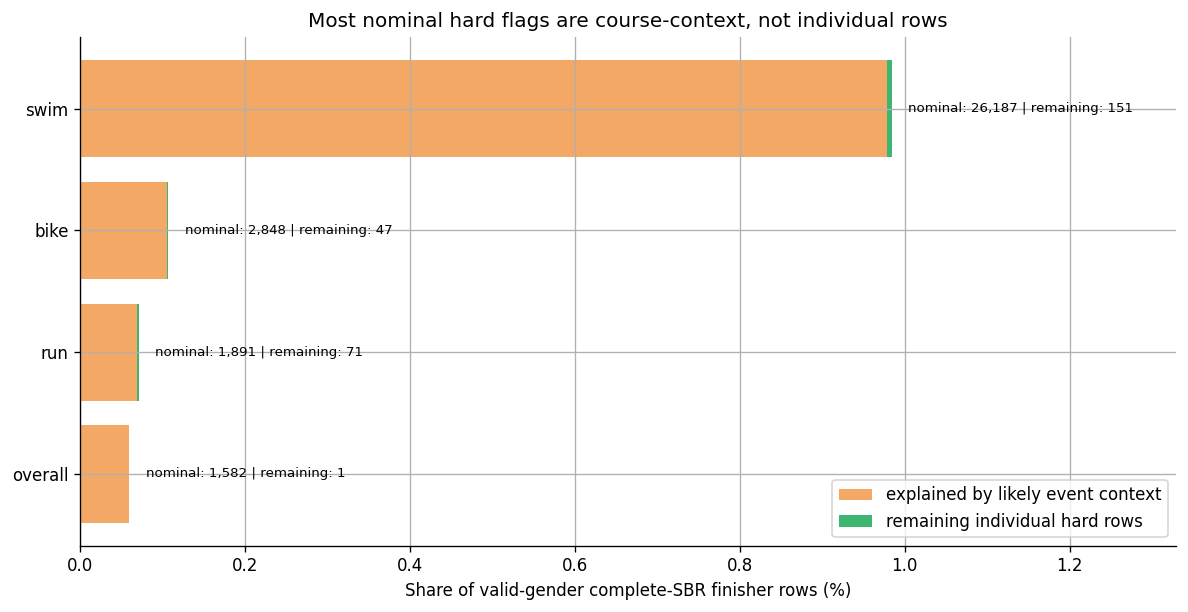

In [61]:
fig, ax = plt.subplots(figsize=(10, 5.2))
plot_df = hard_flag_decomposition_by_leg.iloc[::-1].copy()

ax.barh(
    plot_df["leg"],
    plot_df["context_explained_rate_pct"],
    color="#F2994A",
    alpha=0.85,
    label="explained by likely event context",
)
ax.barh(
    plot_df["leg"],
    plot_df["remaining_individual_hard_rate_pct"],
    left=plot_df["context_explained_rate_pct"],
    color="#27AE60",
    alpha=0.9,
    label="remaining individual hard rows",
)

for y, (_, row) in enumerate(plot_df.iterrows()):
    total = row["context_explained_rate_pct"] + row["remaining_individual_hard_rate_pct"]
    ax.text(
        total + max(plot_df["nominal_hard_rate_pct"].max() * 0.015, 0.02),
        y,
        f"nominal: {row['nominal_hard_rows']:,} | remaining: {row['remaining_individual_hard_rows']:,}",
        va="center",
        fontsize=8,
    )

ax.set_xlabel("Share of valid-gender complete-SBR finisher rows (%)")
ax.set_ylabel("")
ax.set_title("Most nominal hard flags are course-context, not individual rows")
ax.legend(loc="lower right")
ax.set_xlim(0, plot_df["nominal_hard_rate_pct"].max() * 1.35)
plt.tight_layout()

**How to read this output:** use the banded summary first. `event_nominal_hard_rate` means the share of athletes in one event-leg that looks impossible if we assume the nominal distance. For example, if 400 of 1,000 swims exceed the nominal full-distance swim limit, the event-leg hard rate is 40%. That points to course context rather than 400 suspicious athletes.

The bands are intentionally plain:

- `<5%`: normal tail
- `5-20%`: ambiguous review zone
- `20-80%`: likely event context
- `>=80%`: probable event context

The old scatter map is kept as an optional technical audit, but the banded table and small multiples are the better article figures.

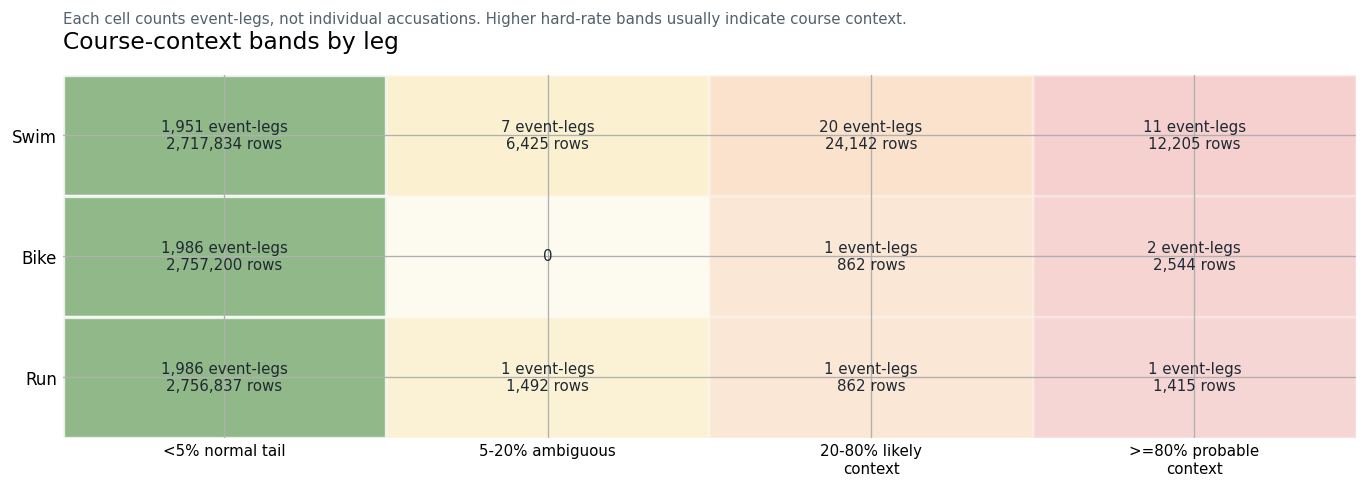

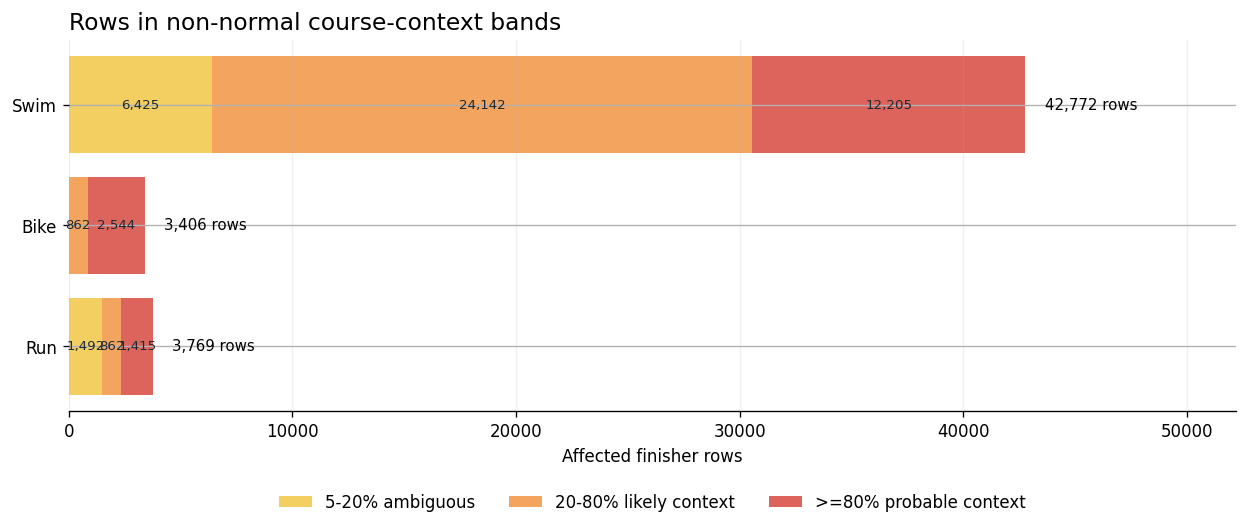

In [62]:
from matplotlib.patches import Rectangle

band_order = CONTEXT_HARD_RATE_BANDS["hard_rate_band"].tolist()
band_labels = CONTEXT_HARD_RATE_BANDS.set_index("hard_rate_band")["band_label"].to_dict()
leg_order = ["swim", "bike", "run"]

context_grid = (
    pd.MultiIndex.from_product([leg_order, band_order], names=["leg", "hard_rate_band"])
    .to_frame(index=False)
    .merge(context_band_summary, on=["leg", "hard_rate_band"], how="left")
    .merge(CONTEXT_HARD_RATE_BANDS[["hard_rate_band", "band_label", "sort_order"]], on="hard_rate_band", how="left", suffixes=("", "_band"))
)
context_grid["event_legs"] = context_grid["event_legs"].fillna(0).astype(int)
context_grid["affected_rows"] = context_grid["affected_rows"].fillna(0).astype(int)
context_grid["band_label"] = context_grid["band_label"].fillna(context_grid["band_label_band"])
context_grid = context_grid.sort_values(["leg", "sort_order"]).reset_index(drop=True)

course_context_band_title = "Course-context bands by leg"
fig, ax = plt.subplots(figsize=(11.5, 4.2))
max_events = safe_max(context_grid["event_legs"], default=1)

for y_idx, leg in enumerate(leg_order):
    for x_idx, band in enumerate(band_order):
        cell = context_grid.loc[context_grid["leg"].eq(leg) & context_grid["hard_rate_band"].eq(band)]
        event_count = int(cell["event_legs"].iloc[0]) if not cell.empty else 0
        row_count = int(cell["affected_rows"].iloc[0]) if not cell.empty else 0
        alpha = 0.22 + 0.58 * np.sqrt(event_count / max_events) if event_count else 0.08
        ax.add_patch(
            Rectangle(
                (x_idx - 0.5, y_idx - 0.5),
                1,
                1,
                facecolor=BAND_COLORS[band],
                edgecolor="white",
                linewidth=2,
                alpha=alpha,
            )
        )
        label = "0" if event_count == 0 else f"{event_count:,} event-legs\n{row_count:,} rows"
        ax.text(x_idx, y_idx, label, ha="center", va="center", fontsize=9, color="#1F2933")

ax.set_xlim(-0.5, len(band_order) - 0.5)
ax.set_ylim(len(leg_order) - 0.5, -0.5)
ax.set_xticks(np.arange(len(band_order)))
ax.set_xticklabels([wrap_label(band_labels[band], 16) for band in band_order], fontsize=9)
ax.set_yticks(np.arange(len(leg_order)))
ax.set_yticklabels([leg.title() for leg in leg_order], fontsize=10)
ax.set_title(course_context_band_title, loc="left", fontsize=14, pad=16)
ax.text(
    -0.5,
    -0.9,
    "Each cell counts event-legs, not individual accusations. Higher hard-rate bands usually indicate course context.",
    ha="left",
    va="bottom",
    fontsize=9,
    color="#52616B",
)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", length=0)
plt.tight_layout()
course_context_band_figure = fig

non_normal_bands = [band for band in band_order if band != "normal_tail"]
non_normal = (
    context_grid.loc[context_grid["hard_rate_band"].isin(non_normal_bands)]
    .pivot_table(index="leg", columns="hard_rate_band", values="affected_rows", aggfunc="sum", fill_value=0)
    .reindex(leg_order)
    .reindex(columns=non_normal_bands, fill_value=0)
)

non_normal_context_title = "Rows in non-normal course-context bands"
fig, ax = plt.subplots(figsize=(10.5, 4.6))
y = np.arange(len(leg_order))
left = np.zeros(len(leg_order))
for band in non_normal_bands:
    values = non_normal[band].to_numpy(dtype=float)
    ax.barh(y, values, left=left, color=BAND_COLORS[band], alpha=0.88, label=band_labels[band])
    for y_idx, value in enumerate(values):
        if value > 0:
            ax.text(left[y_idx] + value / 2, y_idx, f"{int(value):,}", ha="center", va="center", fontsize=8, color="#1F2933")
    left += values

totals = non_normal.sum(axis=1).to_numpy(dtype=float)
for y_idx, total in enumerate(totals):
    if total > 0:
        ax.text(total + safe_max(totals, default=1) * 0.02, y_idx, f"{int(total):,} rows", va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels([leg.title() for leg in leg_order])
ax.invert_yaxis()
ax.set_xlabel("Affected finisher rows")
ax.set_title(non_normal_context_title, loc="left", fontsize=14)
ax.set_xlim(0, safe_max(totals, default=1) * 1.22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.18)
plt.tight_layout()
non_normal_context_figure = fig

SHOW_TECHNICAL_CONTEXT_SCATTER = False
technical_context_scatter_figure = None

if SHOW_TECHNICAL_CONTEXT_SCATTER:
    context_plot = event_leg_context.loc[event_leg_context["rows"].ge(MIN_PUBLIC_COHORT_SIZE)].copy()

    fig, ax = plt.subplots(figsize=(9.5, 6))

    ax.axvspan(0, 5, color="#E8F4EA", alpha=0.7, label="<5%: normal tail")
    ax.axvspan(5, 20, color="#FFF4D6", alpha=0.7, label="5-20%: ambiguous")
    ax.axvspan(20, 80, color="#FCE8D5", alpha=0.7, label="20-80%: likely context")
    ax.axvspan(80, 100, color="#FDE2E1", alpha=0.7, label=">=80%: probable context")
    ax.axhline(POSSIBLE_SHORT_RATIO, color="black", linestyle="--", linewidth=1, alpha=0.8)
    ax.text(1, POSSIBLE_SHORT_RATIO - 0.04, "shorter-than-baseline zone", fontsize=8, va="top")

    leg_colors = {"swim": "#2F80ED", "bike": "#27AE60", "run": "#EB5757"}
    for leg, group in context_plot.groupby("leg"):
        ax.scatter(
            group["nominal_hard_rate"] * 100,
            group["median_duration_ratio"],
            s=np.clip(group["rows"] / 18, 18, 160),
            alpha=0.55,
            color=leg_colors.get(leg, "gray"),
            label=leg,
            edgecolor="white",
            linewidth=0.4,
        )

    ax.set_xlim(-1, 101)
    ax.set_ylim(0, min(2.0, safe_max(context_plot["median_duration_ratio"].quantile([0.995]), default=1.0)))
    ax.set_xlabel("Event-leg nominal hard rate (%)")
    ax.set_ylabel("Median duration ratio versus baseline")
    ax.set_title("Technical appendix: course-context map")
    ax.legend(loc="upper right", title="Leg")
    plt.tight_layout()
    technical_context_scatter_figure = fig

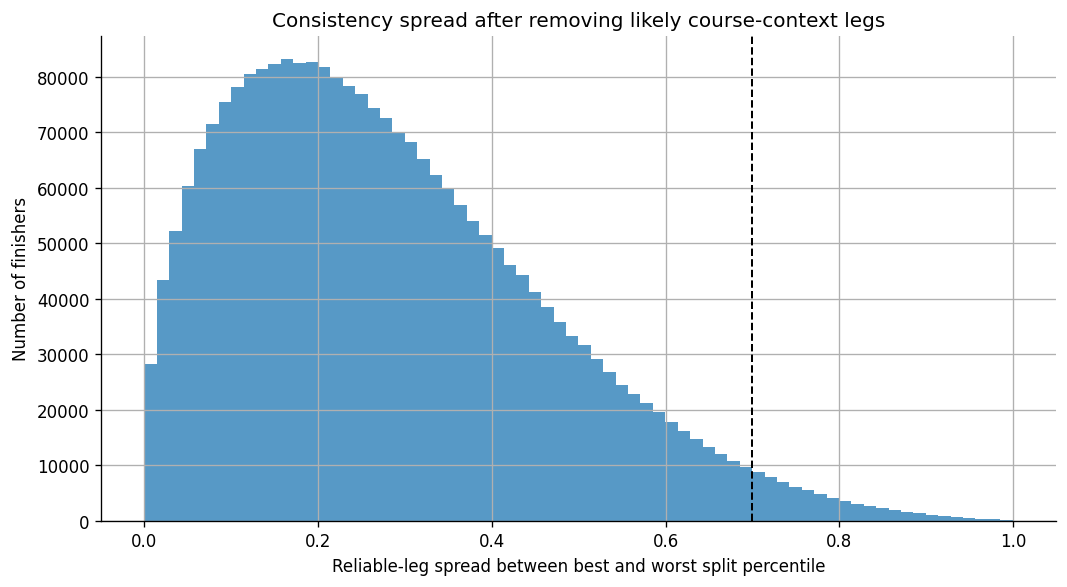

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))
vals = analysis_df.loc[~analysis_df["event_context_flag"], "reliable_spread_rel"].dropna()
ax.hist(vals, bins=70, alpha=0.75)
ax.axvline(SPREAD_REL_THRESHOLD, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Reliable-leg spread between best and worst split percentile")
ax.set_ylabel("Number of finishers")
ax.set_title("Consistency spread after removing likely course-context legs")
plt.tight_layout()

**How to read this output:** each panel has the same denominator but a different meaning. Event context is not athlete suspicion; strict record integrity is hard row failure; individual profile is the remaining unusual-athlete-pattern layer.

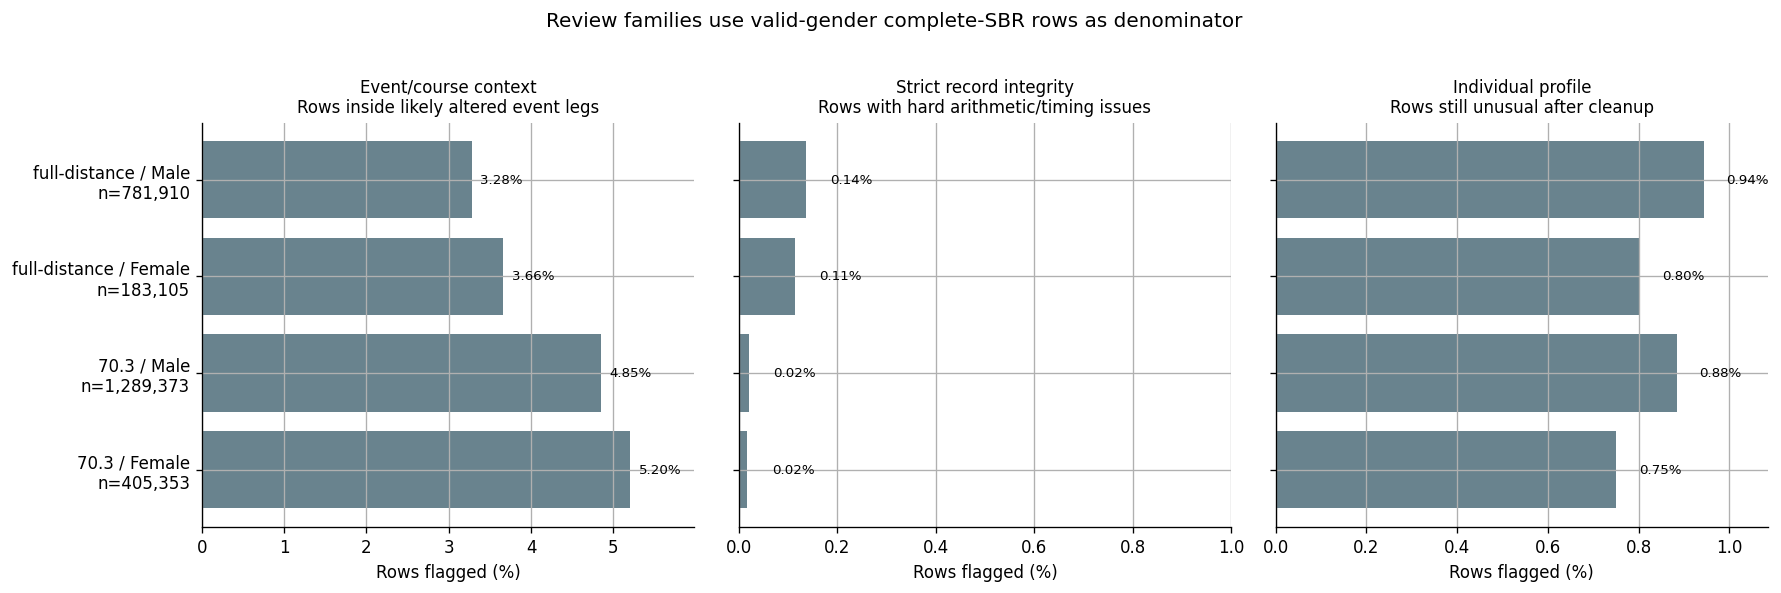

In [64]:
layer_plot = individual_review_summary.loc[individual_review_summary["gender"].isin(VALID_GENDERS)].copy()
layer_plot["cohort_label"] = (
    layer_plot["distance"].astype(str)
    + " / "
    + layer_plot["gender"].astype(str)
    + "\n"
    + "n="
    + layer_plot["n"].map(lambda x: f"{int(x):,}")
)

panels = [
    ("event_context_rate", "Event/course context", "Rows inside likely altered event legs"),
    ("record_integrity_strict_rate", "Strict record integrity", "Rows with hard arithmetic/timing issues"),
    ("individual_profile_rate", "Individual profile", "Rows still unusual after cleanup"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, (col, title, subtitle) in zip(axes, panels):
    values = layer_plot[col] * 100
    ax.barh(layer_plot["cohort_label"], values, color="#4F6D7A", alpha=0.85)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Rows flagged (%)")
    ax.set_xlim(0, max(values.max() * 1.15, 1))
    for y, value in enumerate(values):
        if value > 0:
            ax.text(value + max(values.max() * 0.02, 0.05), y, f"{value:.2f}%", va="center", fontsize=8)

axes[0].set_ylabel("")
fig.suptitle("Review families use valid-gender complete-SBR rows as denominator", y=1.02)
plt.tight_layout()

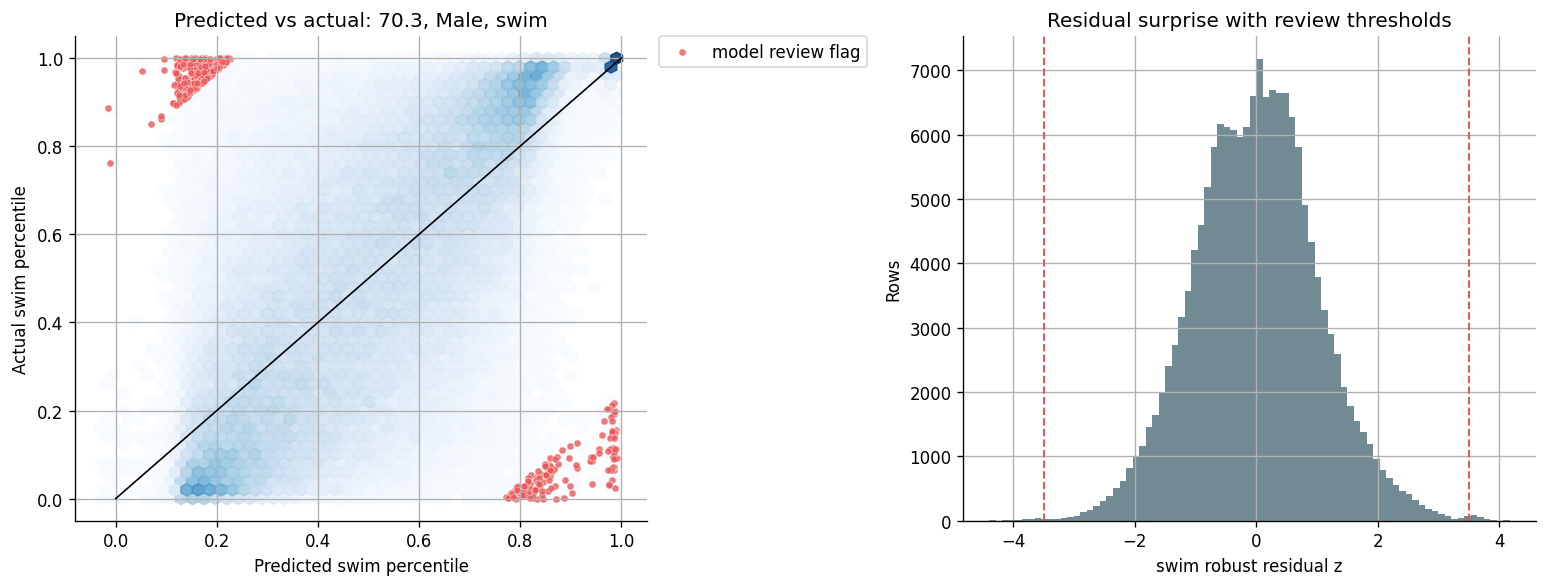

In [65]:
plot_model = (
    model_summary.loc[model_summary["status"].eq("fit")]
    .sort_values(["n_scored", "n_train"], ascending=False)
    .head(1)
)

if not plot_model.empty:
    row = plot_model.iloc[0]
    target = row["target_leg"]
    plot_df = analysis_df.loc[
        analysis_df["distance"].eq(row["distance"]) & analysis_df["gender"].eq(row["gender"])
    ].dropna(subset=[f"{target}_model_pred", f"{target}_rel", f"{target}_model_robust_z"]).copy()

    if len(plot_df) > 180_000:
        flagged_keep = plot_df.loc[plot_df[f"{target}_model_flag"]]
        background_keep = plot_df.loc[~plot_df[f"{target}_model_flag"]].sample(
            min(160_000, (~plot_df[f"{target}_model_flag"]).sum()),
            random_state=RANDOM_STATE,
        )
        plot_df = pd.concat([background_keep, flagged_keep], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    flagged = plot_df[f"{target}_model_flag"]

    hb = axes[0].hexbin(
        plot_df[f"{target}_model_pred"],
        plot_df[f"{target}_rel"],
        gridsize=45,
        mincnt=1,
        cmap="Blues",
        alpha=0.85,
    )
    axes[0].scatter(
        plot_df.loc[flagged, f"{target}_model_pred"],
        plot_df.loc[flagged, f"{target}_rel"],
        s=18,
        color="#EB5757",
        alpha=0.8,
        label="model review flag",
        edgecolor="white",
        linewidth=0.3,
    )
    axes[0].plot([0, 1], [0, 1], color="black", linewidth=1)
    axes[0].set_xlabel(f"Predicted {target} percentile")
    axes[0].set_ylabel(f"Actual {target} percentile")
    axes[0].set_title(f"Predicted vs actual: {row['distance']}, {row['gender']}, {target}")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

    axes[1].hist(plot_df[f"{target}_model_robust_z"].clip(-8, 8), bins=80, color="#4F6D7A", alpha=0.8)
    axes[1].axvline(-MODEL_Z_THRESHOLD, color="#EB5757", linestyle="--", linewidth=1.2)
    axes[1].axvline(MODEL_Z_THRESHOLD, color="#EB5757", linestyle="--", linewidth=1.2)
    axes[1].set_xlabel(f"{target} robust residual z")
    axes[1].set_ylabel("Rows")
    axes[1].set_title("Residual surprise with review thresholds")
    plt.tight_layout()
else:
    print("No fitted model available for model plot.")

**How to read the Huber examples:** these are clean model-flagged rows after removing event-context and strict record-integrity issues. The dumbbell runs from the model's predicted percentile to the actual percentile. A big jump means the leg relationship is unusual, not that the athlete is slow, fast, professional, or guilty.

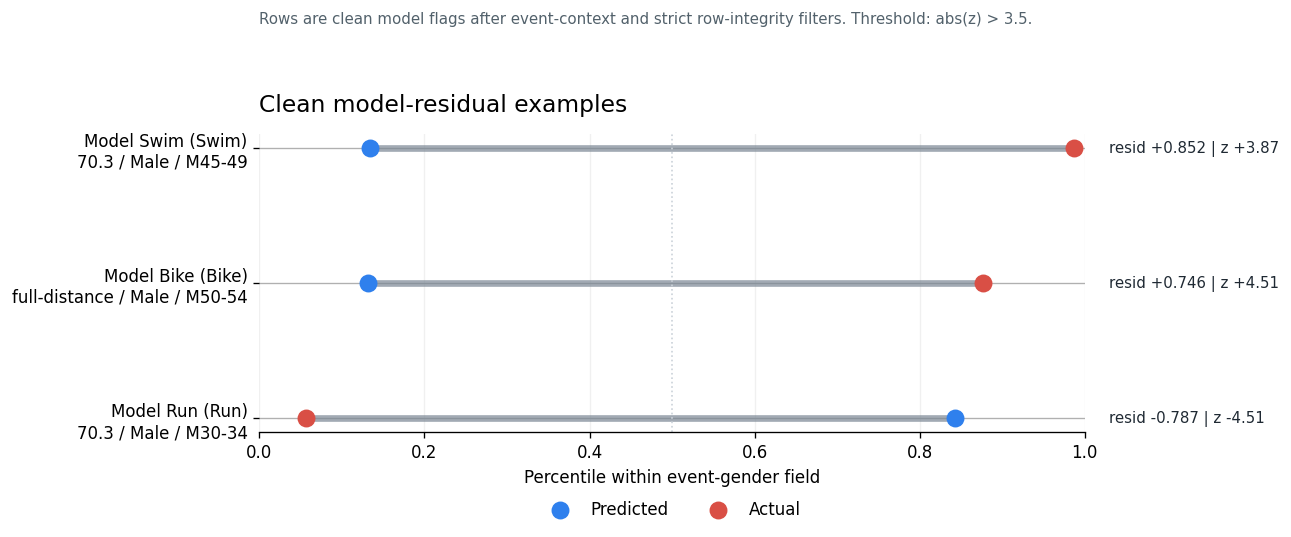

In [66]:
model_dumbbell_title = "Clean model-residual examples"

if model_flag_examples.empty:
    model_dumbbell_figure = None
    print("No clean model-residual examples available.")
else:
    plot_examples = model_flag_examples.copy().reset_index(drop=True)
    plot_examples["label"] = (
        plot_examples["case_id"]
        + " ("
        + plot_examples["target_leg"].str.title()
        + ")\n"
        + plot_examples["distance"].astype(str)
        + " / "
        + plot_examples["gender"].astype(str)
        + " / "
        + plot_examples["division"].astype(str)
    )
    y = np.arange(len(plot_examples))

    fig, ax = plt.subplots(figsize=(10.5, max(3.8, 0.85 * len(plot_examples) + 1.8)))
    for y_idx, (_, row) in enumerate(plot_examples.iterrows()):
        ax.plot(
            [row["predicted_rel"], row["actual_rel"]],
            [y_idx, y_idx],
            color="#7B8794",
            linewidth=4,
            alpha=0.7,
            solid_capstyle="round",
        )
        ax.scatter(row["predicted_rel"], y_idx, color="#2F80ED", s=95, label="Predicted" if y_idx == 0 else "", zorder=3)
        ax.scatter(row["actual_rel"], y_idx, color="#D94F45", s=95, label="Actual" if y_idx == 0 else "", zorder=3)

        residual = row["residual"]
        robust_z = row["robust_z"]
        annotation = f"resid {residual:+.3f} | z {robust_z:+.2f}" if pd.notna(robust_z) else f"resid {residual:+.3f} | z n/a"
        ax.text(1.03, y_idx, annotation, va="center", fontsize=9, transform=ax.get_yaxis_transform(), color="#1F2933")

    ax.axvline(0.5, color="#CBD2D9", linewidth=1, linestyle=":")
    ax.set_xlim(0, 1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_examples["label"])
    ax.invert_yaxis()
    ax.set_xlabel("Percentile within event-gender field")
    ax.set_title(model_dumbbell_title, loc="left", fontsize=14, pad=14)
    ax.text(
        0,
        -0.9,
        f"Rows are clean model flags after event-context and strict row-integrity filters. Threshold: abs(z) > {MODEL_Z_THRESHOLD}.",
        ha="left",
        va="bottom",
        fontsize=9,
        color="#52616B",
    )
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", alpha=0.18)
    plt.subplots_adjust(right=0.78, bottom=0.25, top=0.82)
    model_dumbbell_figure = fig

In [67]:
def sensitivity_table(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for hard_threshold in [0.30, 0.50, 0.80]:
        context_flag = (
            df["swim_event_nominal_hard_rate"].ge(hard_threshold)
            | df["bike_event_nominal_hard_rate"].ge(hard_threshold)
            | df["run_event_nominal_hard_rate"].ge(hard_threshold)
        ).fillna(False)
        rows.append(
            {
                "threshold_family": "event_nominal_hard_rate",
                "threshold": hard_threshold,
                "flag_rate": context_flag.mean(),
                "flagged_rows": int(context_flag.sum()),
            }
        )

    for spread_threshold in [0.65, 0.70, 0.75, 0.80]:
        spread_flag = (
            ~df["event_context_flag"]
            & df["reliable_best_rel"].ge(BEST_REL_THRESHOLD)
            & df["reliable_spread_rel"].ge(spread_threshold)
        )
        rows.append(
            {
                "threshold_family": "consistency_spread",
                "threshold": spread_threshold,
                "flag_rate": spread_flag.mean(),
                "flagged_rows": int(spread_flag.sum()),
            }
        )

    for z_threshold in [3.0, 3.5, 4.0]:
        model_flag = (~df["event_context_flag"] & ~df["record_integrity_flag"] & df["max_model_abs_z"].gt(z_threshold).fillna(False))
        rows.append(
            {
                "threshold_family": "model_abs_robust_z",
                "threshold": z_threshold,
                "flag_rate": model_flag.mean(),
                "flagged_rows": int(model_flag.sum()),
            }
        )

    return pd.DataFrame(rows)


sensitivity = sensitivity_table(analysis_df)
sensitivity.assign(flag_rate_pct=lambda d: d["flag_rate"] * 100)

,threshold_family,threshold,flag_rate,flagged_rows,flag_rate_pct
0,event_nominal_hard_rate,0.30,0.013188,35076,1.318775
1,event_nominal_hard_rate,0.50,0.011347,30181,1.134735
2,event_nominal_hard_rate,0.80,0.005536,14725,0.553625
3,consistency_spread,0.65,0.005063,13467,0.506327
4,consistency_spread,0.70,0.003941,10482,0.394099
5,consistency_spread,0.75,0.002982,7931,0.298187
6,consistency_spread,0.80,0.002182,5804,0.218217
7,model_abs_robust_z,3.00,0.018318,48722,1.831832
8,model_abs_robust_z,3.50,0.005907,15711,0.590697
9,model_abs_robust_z,4.00,0.001998,5314,0.199794


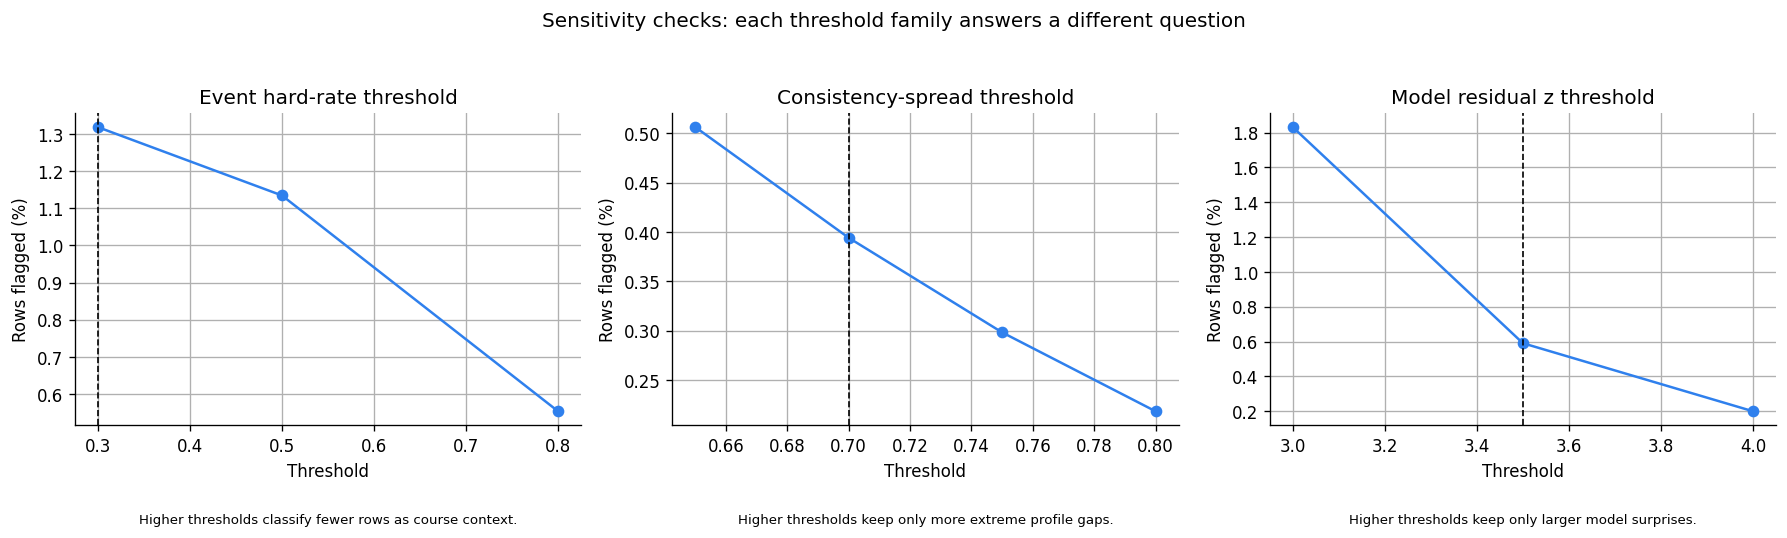

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sensitivity_specs = [
    ("event_nominal_hard_rate", POSSIBLE_CONTEXT_HARD_RATE, "Event hard-rate threshold", "Higher thresholds classify fewer rows as course context."),
    ("consistency_spread", SPREAD_REL_THRESHOLD, "Consistency-spread threshold", "Higher thresholds keep only more extreme profile gaps."),
    ("model_abs_robust_z", MODEL_Z_THRESHOLD, "Model residual z threshold", "Higher thresholds keep only larger model surprises."),
]

for ax, (family, base_threshold, title, note) in zip(axes, sensitivity_specs):
    group = sensitivity.loc[sensitivity["threshold_family"].eq(family)].sort_values("threshold")
    ax.plot(group["threshold"], group["flag_rate"] * 100, marker="o", color="#2F80ED")
    ax.axvline(base_threshold, color="black", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Rows flagged (%)")
    ax.text(0.5, -0.28, note, transform=ax.transAxes, ha="center", va="top", fontsize=8)

fig.suptitle("Sensitivity checks: each threshold family answers a different question", y=1.04)
plt.tight_layout()

## 11. Case evidence and visual cards <a id="cases"></a>

These rows mirror the original example types, but the article-facing output is now evidence-only. Race names, event IDs, names, bibs, countries, source files, and generated verdict sentences are excluded.

Use the table and mini-cards as raw material for the article. The prose interpretation should be written in the article narrative, where you can explain the caveats around event context, row integrity, and individual profile signals.

In [69]:
CASE_SELECTORS = [
    {"case_id": "Case A", "event_id": "ironmancopenhagen2017__388", "gender": "Male", "division": "M30-34", "overall_time": "11:52:26"},
    {"case_id": "Case B", "event_id": "ironman70.3boulder2013__1276", "gender": "Male", "division": "M25-29", "overall_time": "06:15:18"},
    {"case_id": "Case C", "event_id": "ironman70.3jönköping2024__2279", "gender": "Male", "division": "M35-39", "overall_time": "04:31:30"},
    {"case_id": "Case D", "event_id": "ironmancanada2018__439", "gender": "Female", "division": "F40-44", "overall_time": "15:41:49"},
    {"case_id": "Case E", "event_id": "ironman70.3neworleans2014__1339", "gender": "Male", "division": "M30-34", "overall_time": "05:28:09"},
]


def find_case_row(df: pd.DataFrame, selector: dict) -> pd.DataFrame:
    mask = (
        df["event_id"].eq(selector["event_id"])
        & df["gender"].eq(selector["gender"])
        & df["Division"].eq(selector["division"])
        & df["Overall Time"].eq(selector["overall_time"])
    )
    match = df.loc[mask].head(1).copy()
    if not match.empty:
        match["case_id"] = selector["case_id"]
    return match


case_frames = [find_case_row(analysis_df, selector) for selector in CASE_SELECTORS]
case_source = pd.concat([frame for frame in case_frames if not frame.empty], ignore_index=True)

fallback_specs = [
    ("Case A", analysis_df["individual_profile_flag"] & analysis_df["consistency_flag"] & analysis_df["model_layer_flag"]),
    ("Case B", analysis_df["record_integrity_flag"] & (analysis_df["duplicate_time_flag"] | analysis_df["transition_extreme_flag"])),
    ("Case C", analysis_df["event_context_flag"] & analysis_df["nominal_distance_hard_flag"] & ~analysis_df["individual_hard_flag"]),
    ("Case D", analysis_df["individual_profile_flag"] & analysis_df["consistency_flag"] & ~analysis_df["model_layer_flag"]),
    ("Case E", analysis_df["individual_profile_flag"] & analysis_df["model_layer_flag"] & ~analysis_df["consistency_flag"]),
]

existing_case_ids = set(case_source["case_id"]) if not case_source.empty else set()
for case_id, mask in fallback_specs:
    if case_id in existing_case_ids:
        continue
    candidates = analysis_df.loc[mask].copy()
    if not candidates.empty:
        sampled = candidates.sample(1, random_state=100 + ord(case_id[-1])).assign(case_id=case_id)
        case_source = pd.concat([case_source, sampled], ignore_index=True)

case_source = case_source.sort_values("case_id").reset_index(drop=True)
case_source[["case_id", "distance", "gender", "cohort_valid_sbr_finishers", "event_context_flag", "record_integrity_flag", "individual_profile_flag", "swim_rel", "bike_rel", "run_rel", "spread_rel", "max_model_abs_z"]]

,case_id,distance,gender,cohort_valid_sbr_finishers,event_context_flag,record_integrity_flag,individual_profile_flag,swim_rel,bike_rel,run_rel,spread_rel,max_model_abs_z
0,Case A,full-distance,Male,2080,False,False,True,0.971635,0.087981,0.625000,0.883654,3.972140
1,Case B,70.3,Male,957,False,True,False,0.718391,0.146290,0.001045,0.717346,2.109188
2,Case C,70.3,Male,1079,True,False,False,0.234476,0.898981,0.859129,0.664504,2.466591
3,Case D,full-distance,Female,311,False,False,True,0.951768,0.321543,0.099678,0.852090,2.645168
4,Case E,70.3,Male,980,False,False,True,0.924490,0.258163,0.915306,0.666327,3.927957


,case_id,distance,gender,division,cohort_size,flag_families,triggered_layers,event_context_affected_legs,strongest_leg,weakest_leg,swim_rel,bike_rel,run_rel,spread_rel,max_model_abs_z,overall_delta_minutes,event_context_flag,record_integrity_strict_flag,individual_profile_flag,rank_audit_flag
0,Case A,full-distance,Male,M30-34,2080,individual profile + rank audit caveat,consistency spread; model residual: bike; rank...,none,swim,bike,0.972,0.088,0.625,0.884,3.97,0.0,False,False,True,True
1,Case B,70.3,Male,M25-29,957,strict record integrity,reconciliation; duplicate time; extreme transi...,none,swim,run,0.718,0.146,0.001,0.717,2.11,-379.1,False,True,False,True
2,Case C,70.3,Male,M35-39,1079,event context,nominal hard,swim,bike,swim,0.234,0.899,0.859,0.665,2.47,-0.0,True,False,False,False
3,Case D,full-distance,Female,F40-44,311,individual profile + rank audit caveat,consistency spread; rank audit,none,swim,run,0.952,0.322,0.100,0.852,2.65,0.0,False,False,True,True
4,Case E,70.3,Male,M30-34,980,individual profile,model residual: bike,none,swim,bike,0.924,0.258,0.915,0.666,3.93,0.0,False,False,True,False


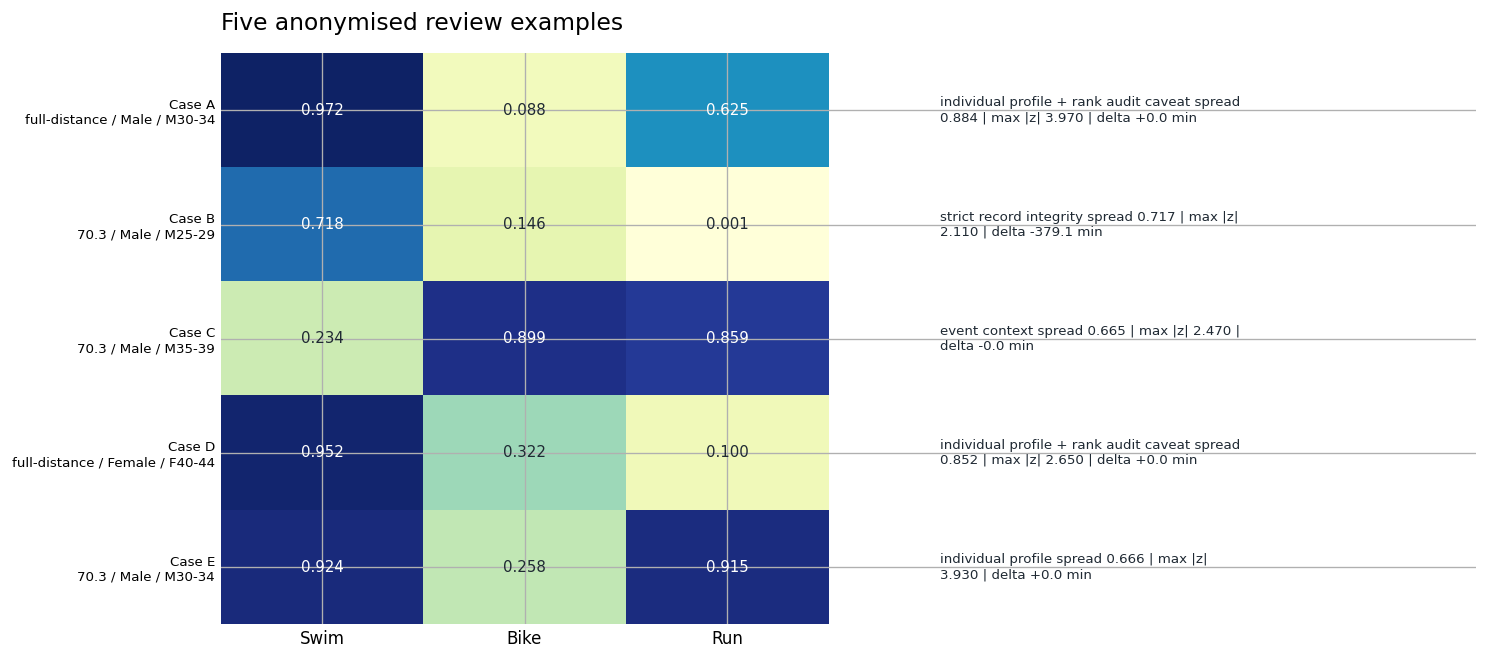

In [72]:
def flag_family_label(row: pd.Series) -> str:
    families = []
    if bool(row["event_context_flag"]):
        families.append("event context")
    if bool(row["record_integrity_strict_flag"]):
        families.append("strict record integrity")
    if bool(row["individual_profile_flag"]):
        families.append("individual profile")
    if bool(row["rank_audit_flag"]) and not bool(row["record_integrity_strict_flag"]):
        families.append("rank audit caveat")
    return " + ".join(families) if families else "low priority"


def triggered_layer_label(row: pd.Series) -> str:
    layers = []
    if bool(row["nominal_distance_hard_flag"]):
        layers.append("nominal hard")
    if bool(row["individual_hard_flag"]):
        layers.append("adjusted hard")
    if bool(row["reconciliation_flag"]):
        layers.append("reconciliation")
    if bool(row["duplicate_time_flag"]):
        layers.append("duplicate time")
    if bool(row["transition_extreme_flag"]):
        layers.append("extreme transition")
    if bool(row["consistency_flag"]):
        layers.append("consistency spread")
    model_legs = [leg for leg in LEG_CONFIG if bool(row[f"{leg}_model_flag"])]
    if model_legs:
        layers.append("model residual: " + ", ".join(model_legs))
    if bool(row["rank_audit_flag"]):
        layers.append("rank audit")
    return "; ".join(layers) if layers else "none"


def rounded_or_nan(value: float, digits: int = 3) -> float:
    return round(float(value), digits) if pd.notna(value) else np.nan


if case_source.empty:
    case_evidence_table = pd.DataFrame()
else:
    evidence_rows = []
    for _, row in case_source.iterrows():
        evidence_rows.append(
            {
                "case_id": row["case_id"],
                "distance": row["distance"],
                "gender": row["gender"],
                "division": row["Division"],
                "cohort_size": int(row["cohort_valid_sbr_finishers"]),
                "flag_families": flag_family_label(row),
                "triggered_layers": triggered_layer_label(row),
                "event_context_affected_legs": row["event_context_affected_legs"],
                "strongest_leg": row["best_leg"],
                "weakest_leg": row["worst_leg"],
                "swim_rel": rounded_or_nan(row["swim_rel"]),
                "bike_rel": rounded_or_nan(row["bike_rel"]),
                "run_rel": rounded_or_nan(row["run_rel"]),
                "spread_rel": rounded_or_nan(row["spread_rel"]),
                "max_model_abs_z": rounded_or_nan(row["max_model_abs_z"], 2),
                "overall_delta_minutes": rounded_or_nan(row["overall_delta_with_transitions_s"] / 60, 1),
                "event_context_flag": bool(row["event_context_flag"]),
                "record_integrity_strict_flag": bool(row["record_integrity_strict_flag"]),
                "individual_profile_flag": bool(row["individual_profile_flag"]),
                "rank_audit_flag": bool(row["rank_audit_flag"]),
            }
        )
    case_evidence_table = pd.DataFrame(evidence_rows)

display(case_evidence_table)

review_examples_title = "Five anonymised review examples"

if case_evidence_table.empty:
    review_examples_matrix_figure = None
    print("No case rows available.")
else:
    matrix = case_evidence_table[["swim_rel", "bike_rel", "run_rel"]].astype(float).to_numpy()
    n_cases = len(case_evidence_table)
    fig, ax = plt.subplots(figsize=(12.5, max(4.2, 0.72 * n_cases + 2.0)))
    im = ax.imshow(matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Swim", "Bike", "Run"])
    ax.set_yticks(np.arange(n_cases))
    ax.set_yticklabels(
        [
            f"{row.case_id}\n{row.distance} / {row.gender} / {row.division}"
            for row in case_evidence_table.itertuples(index=False)
        ],
        fontsize=8,
    )

    for row_idx, row in enumerate(case_evidence_table.itertuples(index=False)):
        for col_idx, value in enumerate([row.swim_rel, row.bike_rel, row.run_rel]):
            color = "white" if pd.notna(value) and value > 0.62 else "#1F2933"
            ax.text(col_idx, row_idx, format_pctile(value), ha="center", va="center", fontsize=9, color=color)

        side_label = (
            f"{row.flag_families}\n"
            f"spread {format_pctile(row.spread_rel)} | max |z| {format_pctile(row.max_model_abs_z)} | "
            f"delta {format_signed_minutes(row.overall_delta_minutes)}"
        )
        ax.text(3.05, row_idx, wrap_label(side_label, 46), va="center", ha="left", fontsize=8, color="#1F2933", clip_on=False)

    ax.set_xlim(-0.5, 5.7)
    ax.set_title(review_examples_title, loc="left", fontsize=14, pad=14)
    ax.text(
        -0.5,
        -0.85,
        "",
        ha="left",
        va="bottom",
        fontsize=9,
        color="#52616B",
    )
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis="both", length=0)
    plt.tight_layout()
    review_examples_matrix_figure = fig

## 12. PRO vs non-PRO sensitivity <a id="pro-sensitivity"></a>

This section is a robustness check, not a replacement for the main workflow. `PRO` means `MPRO` or `FPRO`; every other division remains `non-PRO`.

Event-context detection still uses all valid-gender finishers. That is intentional: a shortened or cancelled swim is an event-level condition, and PRO-only event cohorts are too small for stable race-level charts.

We also keep the main event-gender percentiles. The notebook does not recompute within-PRO event percentiles for article figures, because most PRO event-gender cohorts are small enough to make those percentiles noisy and easier to re-identify.

In [ ]:
PRO_DIVISIONS = {"MPRO", "FPRO"}


def add_division_group(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["division_clean"] = df["Division"].fillna("Unknown").astype(str).str.strip()
    df["division_group"] = np.where(df["division_clean"].str.upper().isin(PRO_DIVISIONS), "PRO", "non-PRO")
    return df


event_context_flag_before_division_group = analysis_df["event_context_flag"].copy()
finishers_for_analysis = add_division_group(finishers_for_analysis)
analysis_df = add_division_group(analysis_df)

division_group_summary = (
    finishers_for_analysis.groupby("division_group", dropna=False)
    .agg(
        finishers=("event_id", "size"),
        complete_sbr_finishers=("complete_sbr", "sum"),
        finishers_share=("event_id", lambda s: len(s) / len(finishers_for_analysis)),
        complete_sbr_rate=("complete_sbr", "mean"),
    )
    .reset_index()
    .sort_values("division_group")
)

division_value_audit = (
    analysis_df.groupby(["division_group", "division_clean"], dropna=False)
    .agg(rows=("event_id", "size"))
    .reset_index()
    .assign(share_of_analysis=lambda d: d["rows"] / len(analysis_df))
    .sort_values("rows", ascending=False)
)

standard_age_group_pattern = r"^[MF]\d{2}-\d{2}$"
non_standard_division_audit = (
    division_value_audit.loc[
        division_value_audit["division_group"].eq("non-PRO")
        & ~division_value_audit["division_clean"].str.upper().str.match(standard_age_group_pattern, na=False)
    ]
    .head(30)
    .reset_index(drop=True)
)

review_family_by_division_group = (
    analysis_df.groupby(["distance", "gender", "division_group"], dropna=False)
    .agg(
        n=("event_id", "size"),
        event_context_rate=("event_context_flag", "mean"),
        record_integrity_strict_rate=("record_integrity_strict_flag", "mean"),
        rank_audit_rate=("rank_audit_flag", "mean"),
        nominal_hard_rate=("nominal_distance_hard_flag", "mean"),
        individual_hard_rate=("individual_hard_flag", "mean"),
        consistency_rate=("consistency_flag", "mean"),
        model_rate=("model_layer_flag", "mean"),
        individual_profile_rate=("individual_profile_flag", "mean"),
        any_review_rate_v2=("any_review_flag_v2", "mean"),
    )
    .reset_index()
)

review_family_overall_by_division_group = (
    analysis_df.groupby("division_group", dropna=False)
    .agg(
        n=("event_id", "size"),
        event_context_rate=("event_context_flag", "mean"),
        record_integrity_strict_rate=("record_integrity_strict_flag", "mean"),
        individual_profile_rate=("individual_profile_flag", "mean"),
        consistency_rate=("consistency_flag", "mean"),
        model_rate=("model_layer_flag", "mean"),
    )
    .reset_index()
)

hard_decomp_division_rows = []
for division_group, group in analysis_df.groupby("division_group", dropna=False):
    for leg in ["swim", "bike", "run", "overall"]:
        nominal_col = f"{leg}_nominal_hard_flag"
        individual_col = f"{leg}_individual_hard_flag"
        context_col = f"{leg}_event_context_flag" if leg != "overall" else "event_context_flag"

        nominal_mask = group[nominal_col]
        context_explained_mask = nominal_mask & group[context_col] & ~group[individual_col]
        individual_mask = group[individual_col]

        hard_decomp_division_rows.append(
            {
                "division_group": division_group,
                "leg": leg,
                "n": len(group),
                "nominal_hard_rows": int(nominal_mask.sum()),
                "context_explained_rows": int(context_explained_mask.sum()),
                "remaining_individual_hard_rows": int(individual_mask.sum()),
                "nominal_hard_rate_pct": nominal_mask.mean() * 100,
                "context_explained_rate_pct": context_explained_mask.mean() * 100,
                "remaining_individual_hard_rate_pct": individual_mask.mean() * 100,
                "share_explained_by_context_pct": (context_explained_mask.sum() / nominal_mask.sum() * 100) if nominal_mask.sum() else 0.0,
            }
        )

hard_decomposition_by_division_group = pd.DataFrame(hard_decomp_division_rows)

model_summary_by_division_group = (
    analysis_df.groupby(["distance", "gender", "division_group"], dropna=False)
    .agg(
        n=("event_id", "size"),
        model_rate=("model_layer_flag", "mean"),
        swim_model_rate=("swim_model_flag", "mean"),
        bike_model_rate=("bike_model_flag", "mean"),
        run_model_rate=("run_model_flag", "mean"),
        median_max_model_abs_z=("max_model_abs_z", "median"),
        p95_max_model_abs_z=("max_model_abs_z", lambda s: s.quantile(0.95)),
    )
    .reset_index()
)

pro_event_gender_cohorts = (
    analysis_df.loc[analysis_df["division_group"].eq("PRO")]
    .groupby(["event_id", "gender"], dropna=False)
    .size()
    .rename("pro_valid_sbr_finishers")
    .reset_index()
)

pro_public_cohort_check = pd.DataFrame(
    [
        {
            "pro_event_gender_cohorts": len(pro_event_gender_cohorts),
            "max_pro_event_gender_cohort": int(pro_event_gender_cohorts["pro_valid_sbr_finishers"].max()) if not pro_event_gender_cohorts.empty else 0,
            "median_pro_event_gender_cohort": float(pro_event_gender_cohorts["pro_valid_sbr_finishers"].median()) if not pro_event_gender_cohorts.empty else np.nan,
            "event_gender_cohorts_ge_public_threshold": int(pro_event_gender_cohorts["pro_valid_sbr_finishers"].ge(MIN_PUBLIC_COHORT_SIZE).sum()) if not pro_event_gender_cohorts.empty else 0,
            "public_threshold": MIN_PUBLIC_COHORT_SIZE,
        }
    ]
)


def fit_division_group_residual_sensitivity(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    trainable_base = ~df["event_context_flag"] & ~df["record_integrity_flag"]

    for division_group in ["PRO", "non-PRO"]:
        division_mask = df["division_group"].eq(division_group)
        for distance in sorted(df.loc[division_mask, "distance"].dropna().unique()):
            for gender in sorted(df.loc[division_mask & df["distance"].eq(distance), "gender"].dropna().unique()):
                group_mask = division_mask & df["distance"].eq(distance) & df["gender"].eq(gender)

                for target_leg in ["swim", "bike", "run"]:
                    target_col = f"{target_leg}_rel"
                    predictor_cols = [f"{leg}_rel" for leg in LEG_CONFIG if leg != target_leg]
                    base_cols = predictor_cols + [target_col, "Division", "event_id"]

                    score_mask = group_mask & df[base_cols].notna().all(axis=1)
                    train_mask = score_mask & trainable_base
                    score_idx = df.index[score_mask]
                    train_idx = df.index[train_mask]

                    if len(score_idx) < MIN_MODEL_ROWS or len(train_idx) < MIN_MODEL_ROWS:
                        rows.append(
                            {
                                "division_group": division_group,
                                "distance": distance,
                                "gender": gender,
                                "target_leg": target_leg,
                                "status": "skipped_too_few_clean_rows",
                                "n_scored": len(score_idx),
                                "n_train_raw": len(train_idx),
                                "n_train_fit": 0,
                                "n_scored_sample": 0,
                                "n_flagged_sample": 0,
                                "flag_rate_sample": np.nan,
                                "resid_scale": np.nan,
                                "mae_train": np.nan,
                                "r2_train": np.nan,
                                "model_confidence": "not_fit",
                            }
                        )
                        continue

                    train_frame = df.loc[train_idx, base_cols].copy()
                    score_frame = df.loc[score_idx, base_cols].copy()

                    train_frame["Division"] = train_frame["Division"].fillna("Unknown").astype(str)
                    score_frame["Division"] = score_frame["Division"].fillna("Unknown").astype(str)

                    if len(train_frame) > MAX_MODEL_TRAIN_ROWS:
                        train_frame = train_frame.sample(MAX_MODEL_TRAIN_ROWS, random_state=RANDOM_STATE)
                    if len(score_frame) > MAX_MODEL_CV_ROWS:
                        score_frame = score_frame.sample(MAX_MODEL_CV_ROWS, random_state=RANDOM_STATE)

                    x_train = pd.get_dummies(train_frame[predictor_cols + ["Division"]], columns=["Division"], drop_first=True, dtype=float)
                    x_score = pd.get_dummies(score_frame[predictor_cols + ["Division"]], columns=["Division"], drop_first=True, dtype=float)
                    x_score, x_train = x_score.align(x_train, join="outer", axis=1, fill_value=0.0)
                    x_train = x_train[x_score.columns]

                    y_train = train_frame[target_col].astype(float)

                    model = HuberRegressor(max_iter=150)
                    model.fit(x_train.to_numpy(), y_train.to_numpy())

                    train_pred = model.predict(x_train.to_numpy())
                    train_resid = y_train.to_numpy() - train_pred
                    resid_center, resid_scale = robust_center_scale(pd.Series(train_resid))

                    pred = model.predict(x_score.to_numpy())
                    actual = score_frame[target_col].astype(float).to_numpy()
                    resid = actual - pred

                    if np.isfinite(resid_scale):
                        robust_z = (resid - resid_center) / resid_scale
                        flags = np.abs(robust_z) > MODEL_Z_THRESHOLD
                    else:
                        robust_z = np.full_like(resid, np.nan, dtype=float)
                        flags = np.zeros_like(resid, dtype=bool)

                    rows.append(
                        {
                            "division_group": division_group,
                            "distance": distance,
                            "gender": gender,
                            "target_leg": target_leg,
                            "status": "fit",
                            "n_scored": len(score_idx),
                            "n_train_raw": len(train_idx),
                            "n_train_fit": len(train_frame),
                            "n_scored_sample": len(score_frame),
                            "n_flagged_sample": int(flags.sum()),
                            "flag_rate_sample": float(flags.mean()) if len(flags) else np.nan,
                            "resid_scale": float(resid_scale) if np.isfinite(resid_scale) else np.nan,
                            "mae_train": float(mean_absolute_error(y_train, train_pred)),
                            "r2_train": float(r2_score(y_train, train_pred)),
                            "model_confidence": model_confidence(len(train_frame), np.nan, resid_scale),
                        }
                    )

    return pd.DataFrame(rows)


pro_model_sensitivity_summary = fit_division_group_residual_sensitivity(analysis_df)

display(division_group_summary.round(4))
display(non_standard_division_audit)
display(review_family_by_division_group.round(4))
display(hard_decomposition_by_division_group.round(3))
display(model_summary_by_division_group.round(4))
display(pro_public_cohort_check)
display(pro_model_sensitivity_summary.round(4))

**How to read this sensitivity check:** PRO rows are useful for checking whether elite athletes are being over-flagged just because they are elite. They are not a good basis for race-level publication charts: PRO event-gender cohorts are much smaller than the public threshold used elsewhere in the notebook.

The main model rates by `division_group` are the article-facing sanity check. The separate PRO/non-PRO Huber models are a calibration stress test. If a PRO-only model produces higher sample flag rates, read that as a sign that the PRO residual scale is much tighter, not as a stronger claim about individual PRO rows.

In [ ]:
pro_review_family_title = "Review-family rates by division group"
review_plot = review_family_overall_by_division_group.copy()
review_plot_long = review_plot.melt(
    id_vars=["division_group", "n"],
    value_vars=[
        "event_context_rate",
        "record_integrity_strict_rate",
        "individual_profile_rate",
        "consistency_rate",
        "model_rate",
    ],
    var_name="review_family",
    value_name="rate",
)
review_plot_long["rate_pct"] = review_plot_long["rate"] * 100
review_labels = {
    "event_context_rate": "Event context",
    "record_integrity_strict_rate": "Strict row integrity",
    "individual_profile_rate": "Individual profile",
    "consistency_rate": "Consistency",
    "model_rate": "Model residual",
}
review_plot_long["review_family_label"] = review_plot_long["review_family"].map(review_labels)

fig, ax = plt.subplots(figsize=(10.5, 5.0))
families = list(review_labels.values())
groups = ["PRO", "non-PRO"]
x = np.arange(len(families))
width = 0.34
colors = {"PRO": "#2F80ED", "non-PRO": "#4F6D7A"}

for offset, division_group in zip([-width / 2, width / 2], groups):
    part = review_plot_long.loc[review_plot_long["division_group"].eq(division_group)].set_index("review_family_label")
    values = part.reindex(families)["rate_pct"].fillna(0)
    ax.bar(x + offset, values, width=width, label=division_group, color=colors[division_group], alpha=0.86)
    for idx, value in enumerate(values):
        if value > 0:
            ax.text(x[idx] + offset, value + max(values.max() * 0.02, 0.02), f"{value:.2f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([wrap_label(label, 14) for label in families])
ax.set_ylabel("Rows flagged (%)")
ax.set_title(pro_review_family_title, loc="left", fontsize=14)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.18)
plt.tight_layout()
pro_review_family_figure = fig

pro_consistency_spread_title = "Consistency spread by division group"
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 50)
for division_group, color in colors.items():
    vals = analysis_df.loc[
        analysis_df["division_group"].eq(division_group)
        & ~analysis_df["event_context_flag"],
        "reliable_spread_rel",
    ].dropna()
    if len(vals) > 150_000:
        vals = vals.sample(150_000, random_state=RANDOM_STATE)
    if not vals.empty:
        ax.hist(vals, bins=bins, density=True, alpha=0.42, color=color, label=f"{division_group} (density)")

ax.axvline(SPREAD_REL_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"spread threshold {SPREAD_REL_THRESHOLD}")
ax.set_xlabel("Reliable-leg percentile spread")
ax.set_ylabel("Density")
ax.set_title(pro_consistency_spread_title, loc="left", fontsize=14)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
pro_consistency_spread_figure = fig

pro_model_residual_title = "Model residual surprise by division group"
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 8, 50)
for division_group, color in colors.items():
    vals = analysis_df.loc[
        analysis_df["division_group"].eq(division_group)
        & ~analysis_df["event_context_flag"]
        & ~analysis_df["record_integrity_flag"],
        "max_model_abs_z",
    ].dropna().clip(0, 8)
    if len(vals) > 150_000:
        vals = vals.sample(150_000, random_state=RANDOM_STATE)
    if not vals.empty:
        ax.hist(vals, bins=bins, density=True, alpha=0.42, color=color, label=f"{division_group} (density)")

ax.axvline(MODEL_Z_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"model threshold {MODEL_Z_THRESHOLD}")
ax.set_xlabel("Maximum model residual |z|")
ax.set_ylabel("Density")
ax.set_title(pro_model_residual_title, loc="left", fontsize=14)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
pro_model_residual_figure = fig

## 13. Validation <a id="validation"></a>

These checks make sure the V2 interpretation behaves as intended.

In [ ]:
IDENTIFYING_COLUMNS = {"Name", "Bib", "Country", "event_id", "source_file"}
PROSE_VERDICT_COLUMNS = {"primary_interpretation", "why_flagged", "caveat", "confidence", "article_safe_sentence"}

article_tables = {
    "flag_taxonomy": flag_taxonomy,
    "cleaning_summary": cleaning_summary,
    "excluded_gender_summary": excluded_gender_summary,
    "event_cleaning_summary": event_cleaning_summary.drop(columns=["event_id"], errors="ignore"),
    "course_context_candidates": course_context_candidates,
    "course_context_summary": course_context_summary,
    "context_band_summary": context_band_summary,
    "individual_review_summary": individual_review_summary,
    "public_race_summary_v2": public_race_summary_v2.drop(columns=["event_id"], errors="ignore"),
    "hard_flag_decomposition": hard_flag_decomposition,
    "hard_flag_decomposition_by_leg": hard_flag_decomposition_by_leg,
    "model_flag_examples": model_flag_examples,
    "case_evidence_table": case_evidence_table,
    "division_group_summary": division_group_summary,
    "non_standard_division_audit": non_standard_division_audit,
    "review_family_by_division_group": review_family_by_division_group,
    "hard_decomposition_by_division_group": hard_decomposition_by_division_group,
    "model_summary_by_division_group": model_summary_by_division_group,
    "pro_public_cohort_check": pro_public_cohort_check,
    "pro_model_sensitivity_summary": pro_model_sensitivity_summary,
}

for table_name, table in article_tables.items():
    leaked_columns = IDENTIFYING_COLUMNS.intersection(table.columns)
    assert not leaked_columns, f"{table_name} contains identifying columns: {sorted(leaked_columns)}"

case_prose_columns = PROSE_VERDICT_COLUMNS.intersection(case_evidence_table.columns)
assert not case_prose_columns, f"case_evidence_table contains prose verdict columns: {sorted(case_prose_columns)}"

missing_registry = sorted(set(THRESHOLD_CONSTANTS) - set(PARAMETER_REGISTRY["parameter"]))
assert not missing_registry, f"Thresholds missing from PARAMETER_REGISTRY: {missing_registry}"

expected_columns = [
    "event_context_flag",
    "event_context_affected_legs",
    "record_integrity_strict_flag",
    "rank_audit_flag",
    "record_integrity_flag",
    "nominal_distance_hard_flag",
    "individual_hard_flag",
    "individual_profile_flag",
    "any_review_flag_v2",
    "division_group",
    "reconciliation_flag",
    "duplicate_time_flag",
    "transition_review_flag",
    "transition_extreme_flag",
    "rank_time_mismatch_flag",
    "swim_event_context_flag",
    "bike_event_context_flag",
    "run_event_context_flag",
    "swim_individual_hard_flag",
    "bike_individual_hard_flag",
    "run_individual_hard_flag",
    "consistency_flag",
    "one_leg_spike_flag",
    "one_leg_collapse_flag",
    "multi_leg_gap_flag",
    "swim_model_robust_z",
    "bike_model_robust_z",
    "run_model_robust_z",
]

missing_columns = [col for col in expected_columns if col not in analysis_df.columns]
assert not missing_columns, f"Missing expected analysis columns: {missing_columns}"
assert set(analysis_df["gender"].dropna().unique()).issubset(set(VALID_GENDERS)), "analysis_df should contain only valid genders."
assert int(excluded_gender_summary["rows"].sum()) == int((~finishers["valid_gender"]).sum()), "Missing/unknown gender rows are not counted correctly."
assert analysis_df.loc[analysis_df["rank_audit_flag"] & ~analysis_df["record_integrity_strict_flag"], "record_integrity_flag"].sum() == 0, "Rank-only audit rows should not be strict record-integrity rows."
assert analysis_df["model_layer_flag"].equals(analysis_df[MODEL_FLAG_COLS].any(axis=1)), "model_layer_flag should be the union of the three leg model flags."

assert set(analysis_df["division_group"].dropna().unique()).issubset({"PRO", "non-PRO"}), "division_group should contain only PRO and non-PRO."
pro_divisions_observed = set(analysis_df.loc[analysis_df["division_group"].eq("PRO"), "division_clean"].str.upper().unique())
assert pro_divisions_observed.issubset(PRO_DIVISIONS), f"Unexpected PRO divisions: {sorted(pro_divisions_observed - PRO_DIVISIONS)}"
assert analysis_df.loc[analysis_df["division_clean"].str.upper().isin(PRO_DIVISIONS), "division_group"].eq("PRO").all(), "MPRO/FPRO rows must be classified as PRO."
assert analysis_df["event_context_flag"].equals(event_context_flag_before_division_group), "Adding division_group should not change event-context flags."
assert int(pro_public_cohort_check["event_gender_cohorts_ge_public_threshold"].iloc[0]) == 0, "PRO event-gender cohorts should not be used as public race-level charts at the current threshold."

fit_models = model_summary.loc[model_summary["status"].eq("fit")].copy()
if not fit_models.empty:
    assert fit_models["gender"].isin(VALID_GENDERS).all(), "Fitted model summary should contain only valid genders."
    assert not fit_models.duplicated(["distance", "gender", "target_leg"]).any(), "Each fitted model should be unique by distance, gender, and target leg."

skipped_sensitivity = pro_model_sensitivity_summary.loc[pro_model_sensitivity_summary["status"].eq("skipped_too_few_clean_rows")]
if not skipped_sensitivity.empty:
    assert (
        skipped_sensitivity["n_train_raw"].lt(MIN_MODEL_ROWS)
        | skipped_sensitivity["n_scored"].lt(MIN_MODEL_ROWS)
    ).all(), "Sensitivity models should only skip rows below the minimum model size."

if not model_flag_example_audit.empty:
    assert not model_flag_example_audit["event_context_flag"].any(), "Model examples should exclude event-context rows."
    assert not model_flag_example_audit["record_integrity_strict_flag"].any(), "Model examples should exclude strict record-integrity rows."

if not case_evidence_table.empty:
    assert not case_evidence_table["division"].astype(str).str.upper().isin(PRO_DIVISIONS).any(), "Publication case examples should not include individual PRO rows by default."
if not model_flag_examples.empty:
    assert not model_flag_examples["division"].astype(str).str.upper().isin(PRO_DIVISIONS).any(), "Publication model examples should not include individual PRO rows by default."

for _, row in hard_flag_decomposition_by_leg.iterrows():
    assert row["context_explained_rows"] + row["remaining_individual_hard_rows"] <= row["nominal_hard_rows"], "Hard-flag decomposition cannot exceed nominal hard rows."

known_event_patterns = {
    "ironmanlouisville2018": "swim",
    "ironmansouthafrica2021": "swim",
    "ironmansouthafrica2023": "swim",
    "ironmannewzealand2012": "any",
}

known_event_checks = []
for pattern, expected_leg in known_event_patterns.items():
    matched = analysis_df.loc[analysis_df["event_id"].str.contains(pattern, case=False, regex=False)]
    if matched.empty:
        known_event_checks.append({"pattern": pattern, "present": False, "classified": np.nan})
        continue

    if expected_leg == "any":
        classified = bool(matched["event_context_flag"].any())
    else:
        classified = bool(matched[f"{expected_leg}_event_context_flag"].any())

    known_event_checks.append({"pattern": pattern, "present": True, "classified": classified})
    assert classified, f"Known modified event pattern was not classified as context: {pattern}"

known_event_checks = pd.DataFrame(known_event_checks)

expected_figures = {
    "course_context_band_figure": course_context_band_figure,
    "non_normal_context_figure": non_normal_context_figure,
    "model_dumbbell_figure": model_dumbbell_figure,
    "review_examples_matrix_figure": review_examples_matrix_figure,
    "pro_review_family_figure": pro_review_family_figure,
    "pro_consistency_spread_figure": pro_consistency_spread_figure,
    "pro_model_residual_figure": pro_model_residual_figure,
}
assert expected_figures["course_context_band_figure"] is not None, "Course-context band figure was not created."
assert expected_figures["non_normal_context_figure"] is not None, "Non-normal context figure was not created."
assert expected_figures["pro_review_family_figure"] is not None, "PRO review-family figure was not created."
assert expected_figures["pro_consistency_spread_figure"] is not None, "PRO consistency-spread figure was not created."
assert expected_figures["pro_model_residual_figure"] is not None, "PRO model-residual figure was not created."
if not model_flag_examples.empty:
    assert expected_figures["model_dumbbell_figure"] is not None, "Model dumbbell figure was not created."
if not case_evidence_table.empty:
    assert expected_figures["review_examples_matrix_figure"] is not None, "Review examples matrix was not created."

figure_titles = [
    course_context_band_title,
    non_normal_context_title,
    model_dumbbell_title,
    review_examples_title,
    pro_review_family_title,
    pro_consistency_spread_title,
    pro_model_residual_title,
]
blocked_title_terms = ["article-safe", "suspicious", "verdict"]
for title in figure_titles:
    lowered = title.lower()
    for term in blocked_title_terms:
        assert term not in lowered, f"Figure title contains non-article wording: {title}"

notebook_text = Path("notebooks/05_chasing_ghosts_flagship.ipynb").read_text(encoding="utf-8")
for phrase in [
    "conservative defaults",
    "HuberRegressor",
    "Review families",
    "How to read this output",
    "event_nominal_hard_rate",
    "model robust z",
    "Professionals are not automatically flagged",
    "PRO vs non-PRO sensitivity",
]:
    assert phrase in notebook_text, f"Expected explanatory notebook phrase is missing: {phrase}"

for old_name in ["any_review" + "_flag", "race" + "_leaderboard", "case_explanation" + "_table"]:
    import re
    pattern = rf"(?<![A-Za-z0-9_]){re.escape(old_name)}(?![A-Za-z0-9_])"
    assert re.search(pattern, notebook_text) is None, f"Old reference remains in notebook text: {old_name}"

print("Validation checks passed.")
display(known_event_checks)

## 14. Article summary <a id="summary"></a>

The improved article thesis is:

> Some anomalies are athletes, some are rows, and some are whole races.

The notebook now makes that distinction explicit. A 100% swim hard-rate is no longer presented as hundreds of individual red flags; it is treated as evidence that the swim was probably shortened, cancelled, or recorded under a different course context.

The case section gives anonymised evidence rather than verdict prose. Use the evidence table, review examples matrix, and Huber residual examples to write the explanation in your own article voice.

The PRO/non-PRO section is a sensitivity check: it helps answer whether elite athletes are being over-flagged simply because they are elite, while keeping non-PRO rows as the main article population for individual-profile discussion.